# [LAB 07] 추론통계 - 4. 대응표본 T-Test

### 1. 패키지 설치 

In [1]:
!pip install --upgrade statannotations


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. 라이브러리 참조 

In [2]:
from jussam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame

# 가설 검정 가정에 따른 가정 방법 선택을 위한 라이브러리 
from scipy.stats import ttest_rel, wilcoxon

# 시각화에 필요한 라이브러리 
from statannotations.Annotator import Annotator

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


## #02. 예제(1) - 사슴의 다리 길이 비교 

### 1. 데이터 가져오기 

In [3]:
df1 = load_data("deer")
df1.head()

📚 사슴의 왼쪽 앞다리와 왼쪽 뒷다리의 길이를 측정한 자료 (출처: 방송통신대학교 통계학개론)


,앞다리,뒷다리
사슴,,
1,138,142
2,136,140
3,147,144
4,139,144
5,143,142


### 2. 시각화를 위해 long 타입으로 데이터 재배치 

In [4]:
df1_melt = melt(df1, var_name="group", value_name="length")
df1_melt.head()

,group,length
0,앞다리,138
1,앞다리,136
2,앞다리,147
3,앞다리,139
4,앞다리,143


### 3. 데이터 분포 시각화 

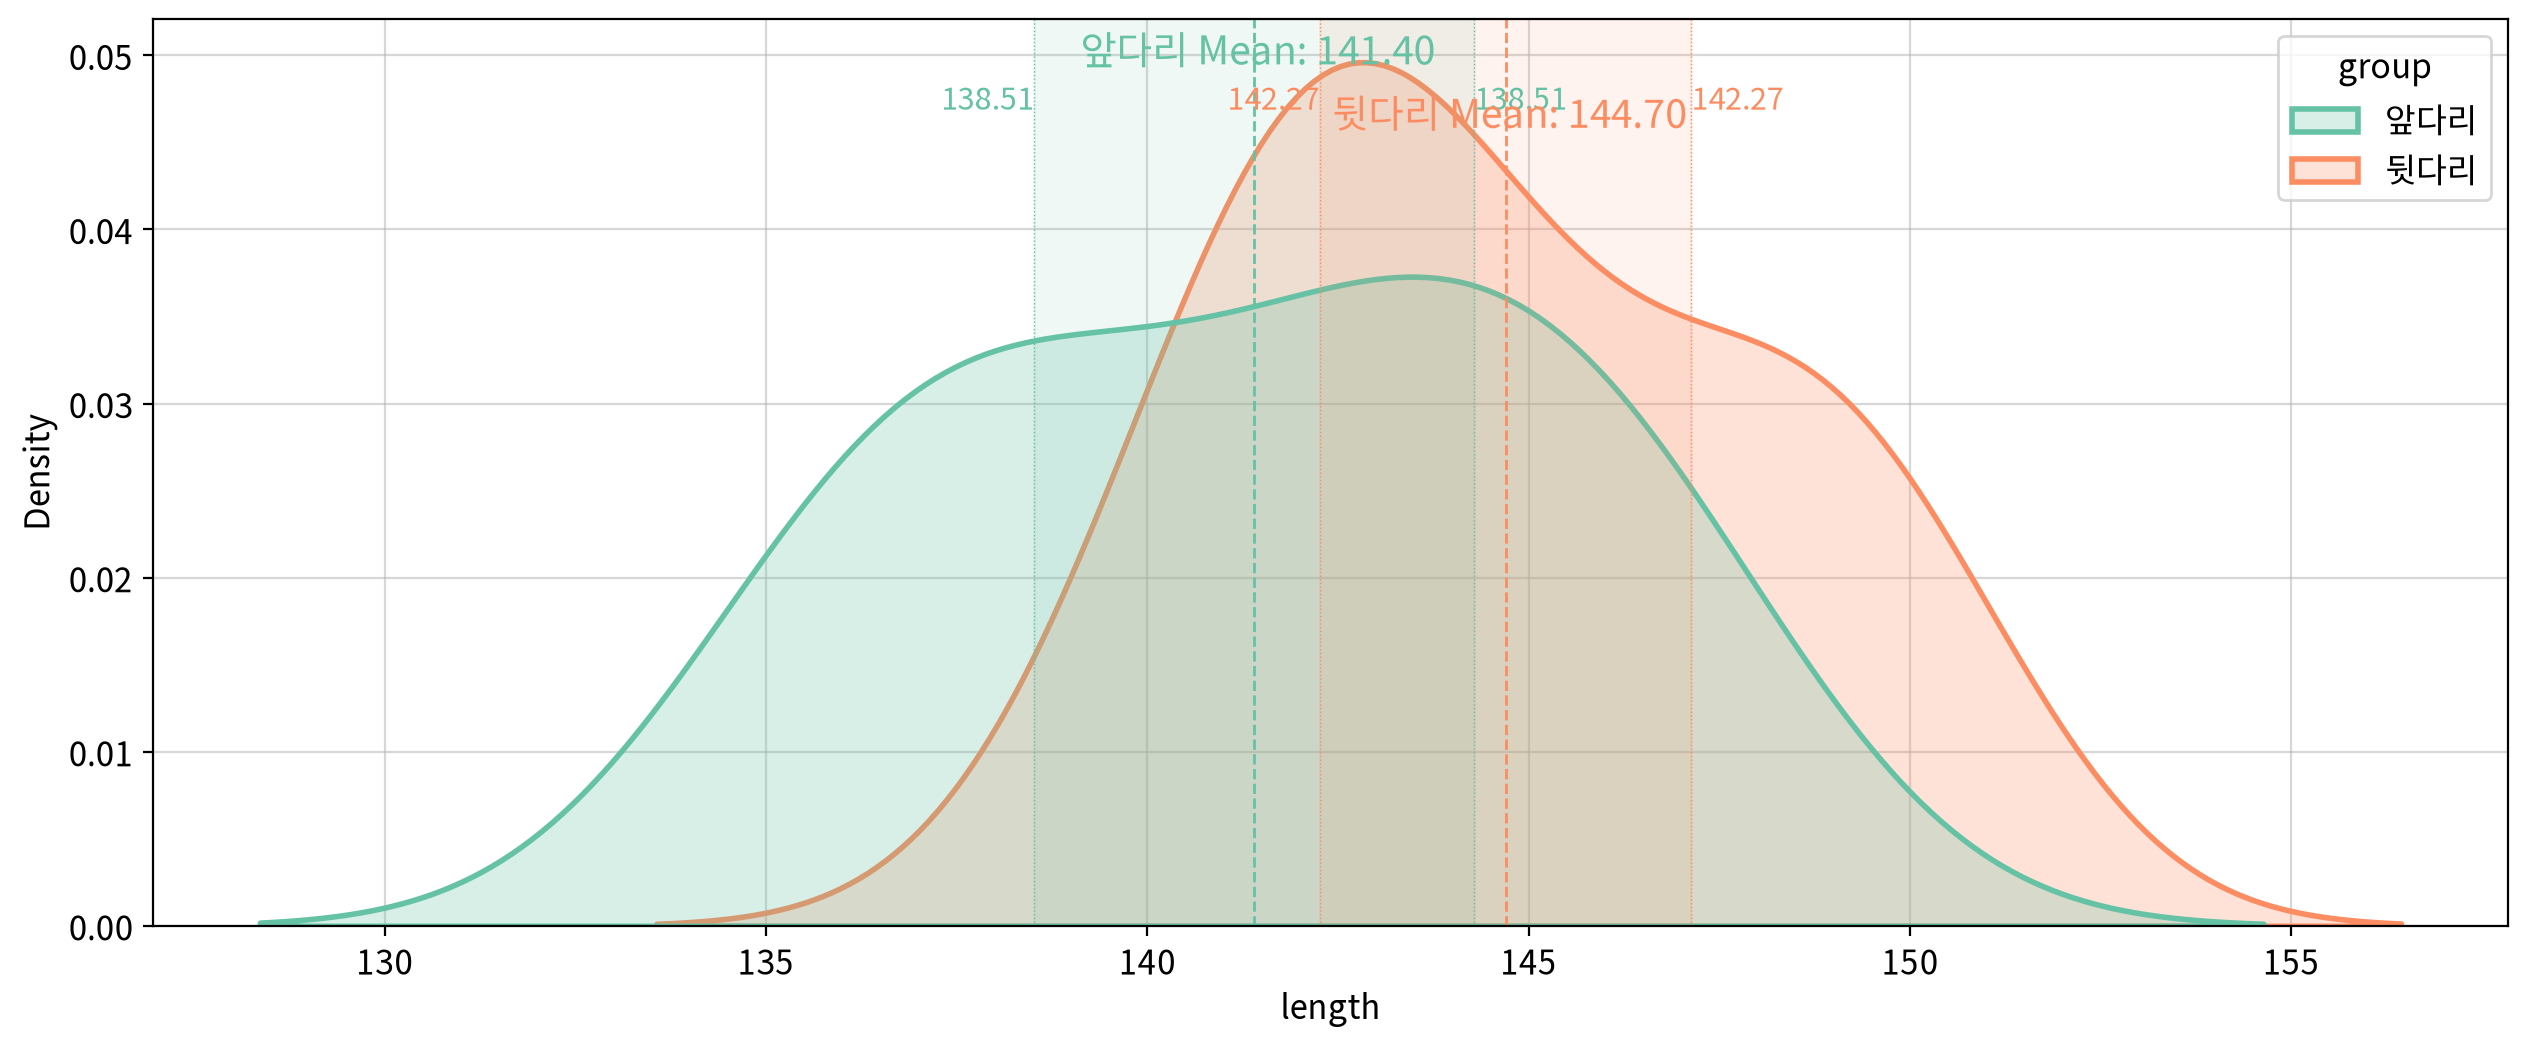

In [5]:
my_plot.kdeplot(data=df1_melt, x='length', hue='group', 
                fill=True, meanline=True, clevel=0.95, palette='Set2')

### 4. 가설검정의 가정을 확인하기 위한 파생변수 생성 

In [6]:
df1_diff = df1.copy()
df1_diff['diff'] = df1_diff['뒷다리'] - df1_diff['앞다리']
df1_diff.head()

,앞다리,뒷다리,diff
사슴,,,
1,138,142,4
2,136,140,4
3,147,144,-3
4,139,144,5
5,143,142,-1


### 5. 차이값에 대한 정규성 검정 

In [7]:
my_stats.test_assumptions(data=df1_diff, columns='diff')

,test,statistic,p-value,result
field,,,,
diff,normaltest,4.356,0.113,True


### 6. Paired T-Test 양측검정 

In [8]:
s, p = ttest_rel(df1['뒷다리'], df1['앞다리'], 
                 alternative='two-sided')
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")    

t-statistic: 3.4138, p-value: 0.0077


### 7. Paired T-Test 좌측 단측검정 

In [9]:
s, p = ttest_rel(df1['뒷다리'], df1['앞다리'], 
                 alternative='less')
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")    

t-statistic: 3.4138, p-value: 0.9961


### 8. Paired T-Test 우측 단측검정 

In [10]:
s, p = ttest_rel(df1['뒷다리'], df1['앞다리'], 
                 alternative='greater')
print(f"t-statistic: {s:.4f}, p-value: {p:.4f}")    

t-statistic: 3.4138, p-value: 0.0039


### 9. 가설검정 시각화 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

앞다리 vs. 뒷다리: t-test paired samples, P_val:7.703e-03 t=-3.414e+00


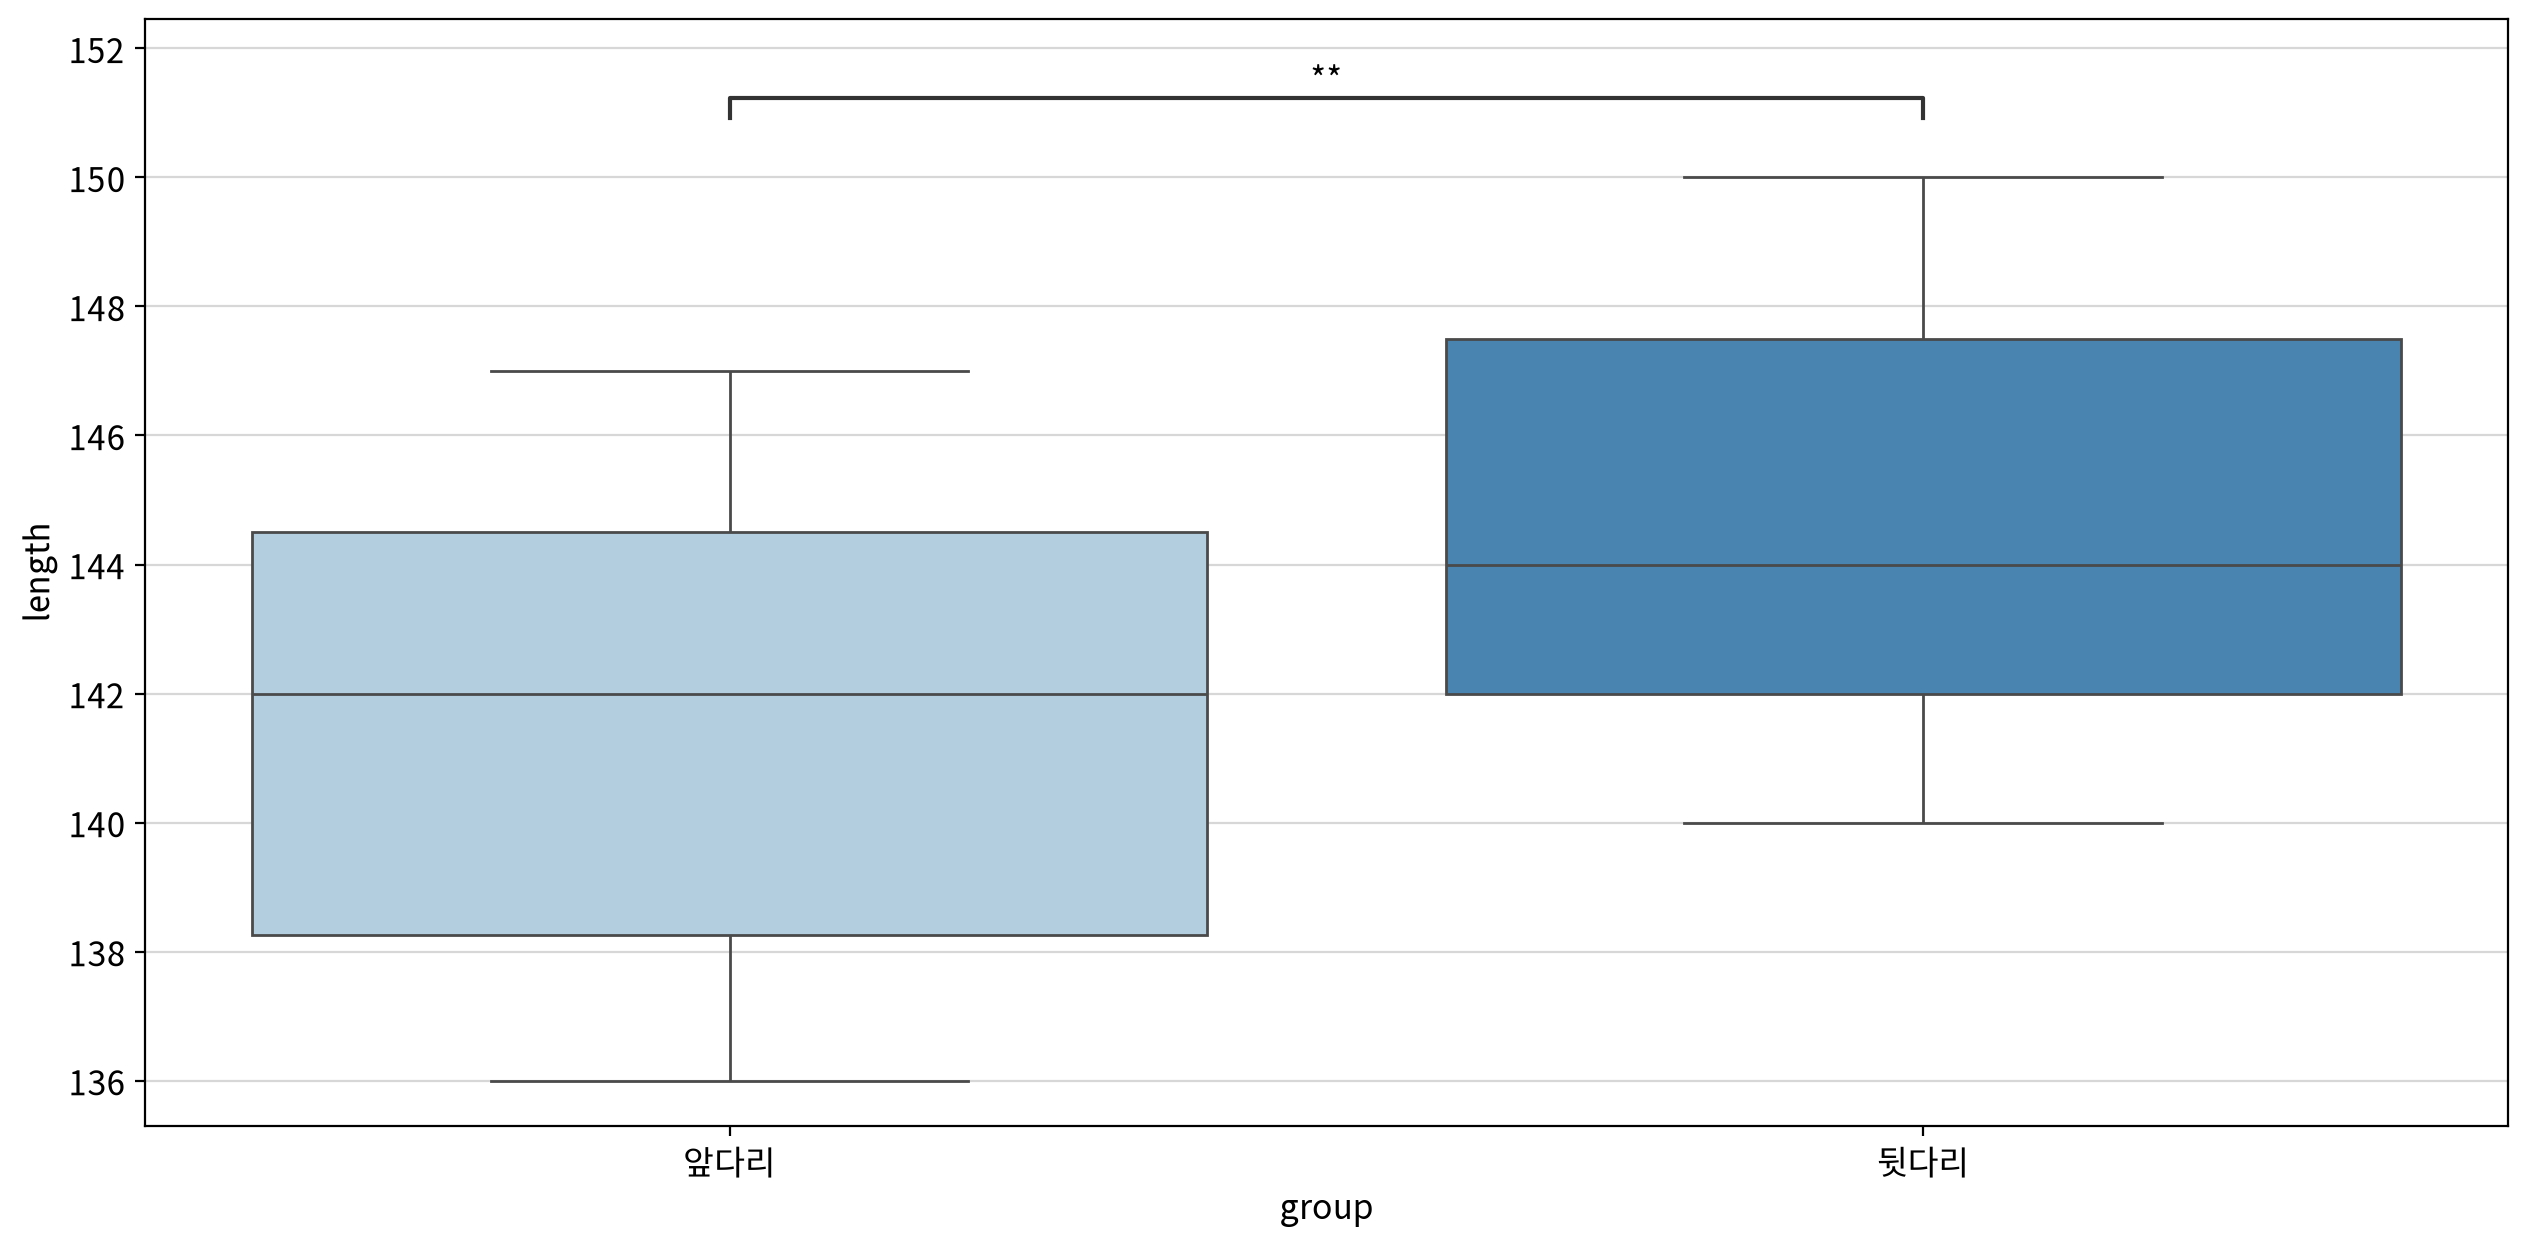

In [11]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df1_melt, 
                x="group", y="length", hue="group", 
                palette="Blues", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가 
annotator = Annotator(data=df1_melt, 
                      x='group', 
                      y='length', 
                      pairs=[('앞다리', '뒷다리')], 
                      ax=ax
                      )

# 가설검정 알고리즘 종류 ( 't-test_ind', 't-test_paired', 't-test_welch', 'Mann-Whitney',
# 'Mann-Whitney-gt', 'Mann-Whitney-ls', 'Levene', 'Wilcoxon', 'Kruskal' 등을 지원)

annotator.configure(test='t-test_paired')
annotator.apply_and_annotate()

my_plot.show()

## #03. 예제(2) - 자동차 첨가제가 주행거리에 미치는 영향 

### 1. 데이터 가져오기 

In [12]:
df2 = load_data('oil')
df2

📚 다섯 종류의 새 차에 대하여 같은 종류의 차 두 대 중에서 한 대를 랜덤하게 선택하여 첨가제를 사용하고, 다른 한 대에는 첨가제를 사용하지 않고 같은 운전자가 같은 장소에서 운전한 후 주행거리를 측정한 결과 데이터 (출처: 방송통신대학교 통계학개론)


,그룹A,그룹B
0,13.200,11.700
1,13.100,17.984
2,16.300,12.290
3,14.900,9.862
4,14.200,8.871
5,16.100,37.034
6,15.100,25.111
7,13.600,12.728
8,15.800,11.346
9,14.200,8.400


### 2. 시각화를 위한 데이터 재배치 

In [13]:
df2_melt = melt(df2, var_name="group", value_name="length")
df2_melt.head()

,group,length
0,그룹A,13.200
1,그룹A,13.100
2,그룹A,16.300
3,그룹A,14.900
4,그룹A,14.200


### 3. 데이터 분포 시각화 

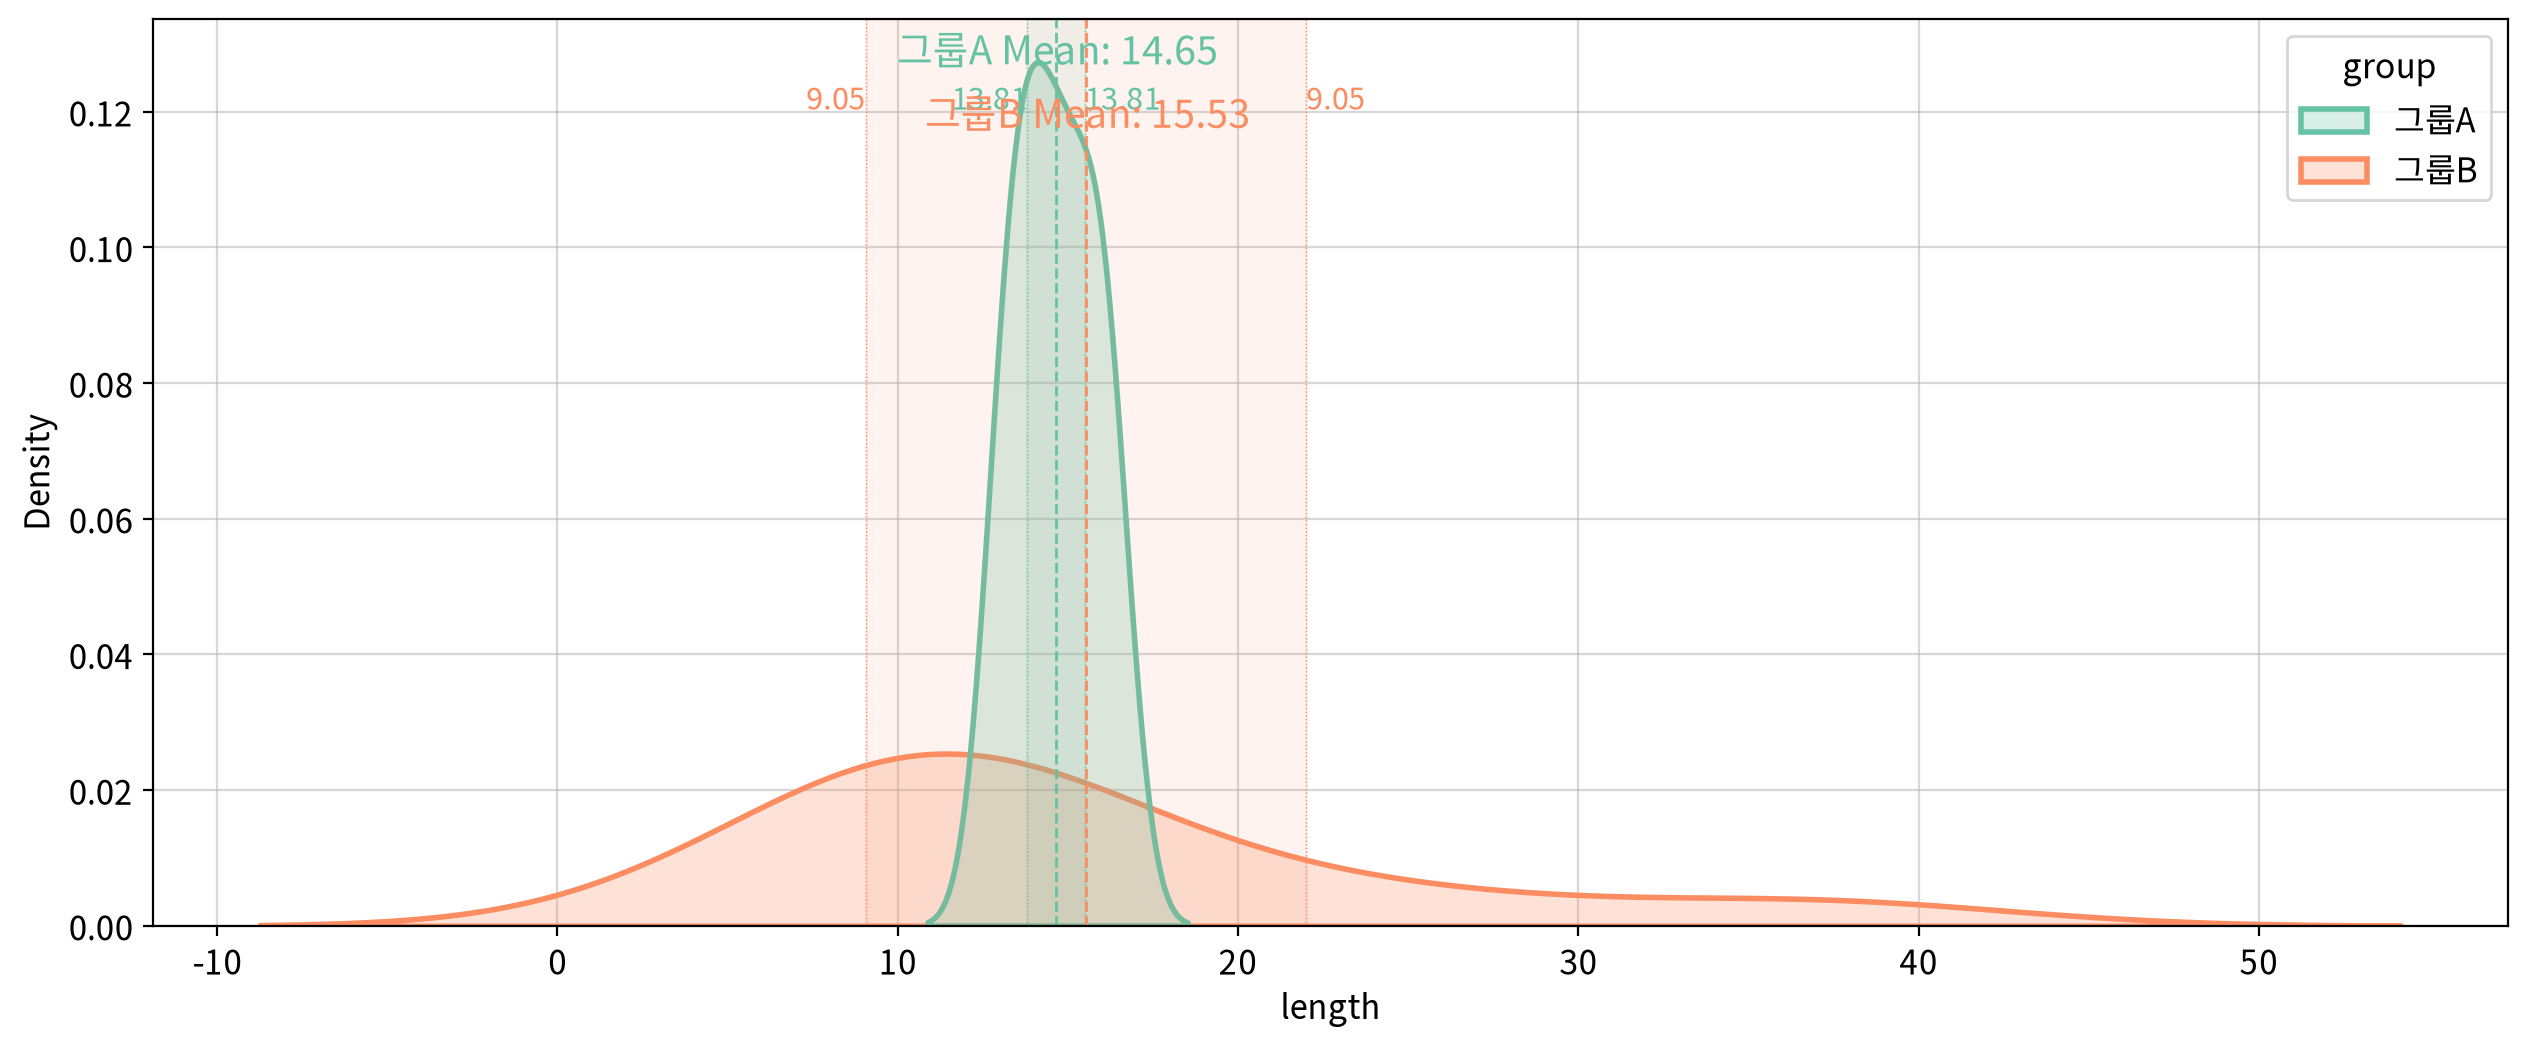

In [14]:
my_plot.kdeplot(data=df2_melt, x='length', hue='group', 
                fill=True, meanline=True, clevel=0.95, palette='Set2')

### 4. 가설검정 가정 확인 

In [15]:
# 차이값 계산 
df2_diff = df2.copy()
df2_diff['diff'] = df2_diff['그룹B'] - df2_diff['그룹A']

# 차이에 대한 정규성 검정 
my_stats.test_assumptions(data=df2_diff, columns='diff')

,test,statistic,p-value,result
field,,,,
diff,normaltest,7.990,0.018,False


### 5. Wilcoxon sigend-rank test 양측 검정 

In [16]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='two-sided')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 24.0000, p-value: 0.7695


### 6. Wilcoxon sigend-rank test 좌측 단측 검정 

In [17]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='less')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 31.0000, p-value: 0.6523


### 7. Wilcoxon Sigend-rank test 우측 단측 검정 

In [18]:
s, p = wilcoxon(df2['그룹A'], df2['그룹B'], alternative='greater')
print(f"Wilcoxon statistic: {s:.4f}, p-value: {p:.4f}")

Wilcoxon statistic: 31.0000, p-value: 0.3848


### 8. 가설검정 시각화 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹A vs. 그룹B: Wilcoxon test (paired samples), P_val:7.695e-01 Stat=2.400e+01


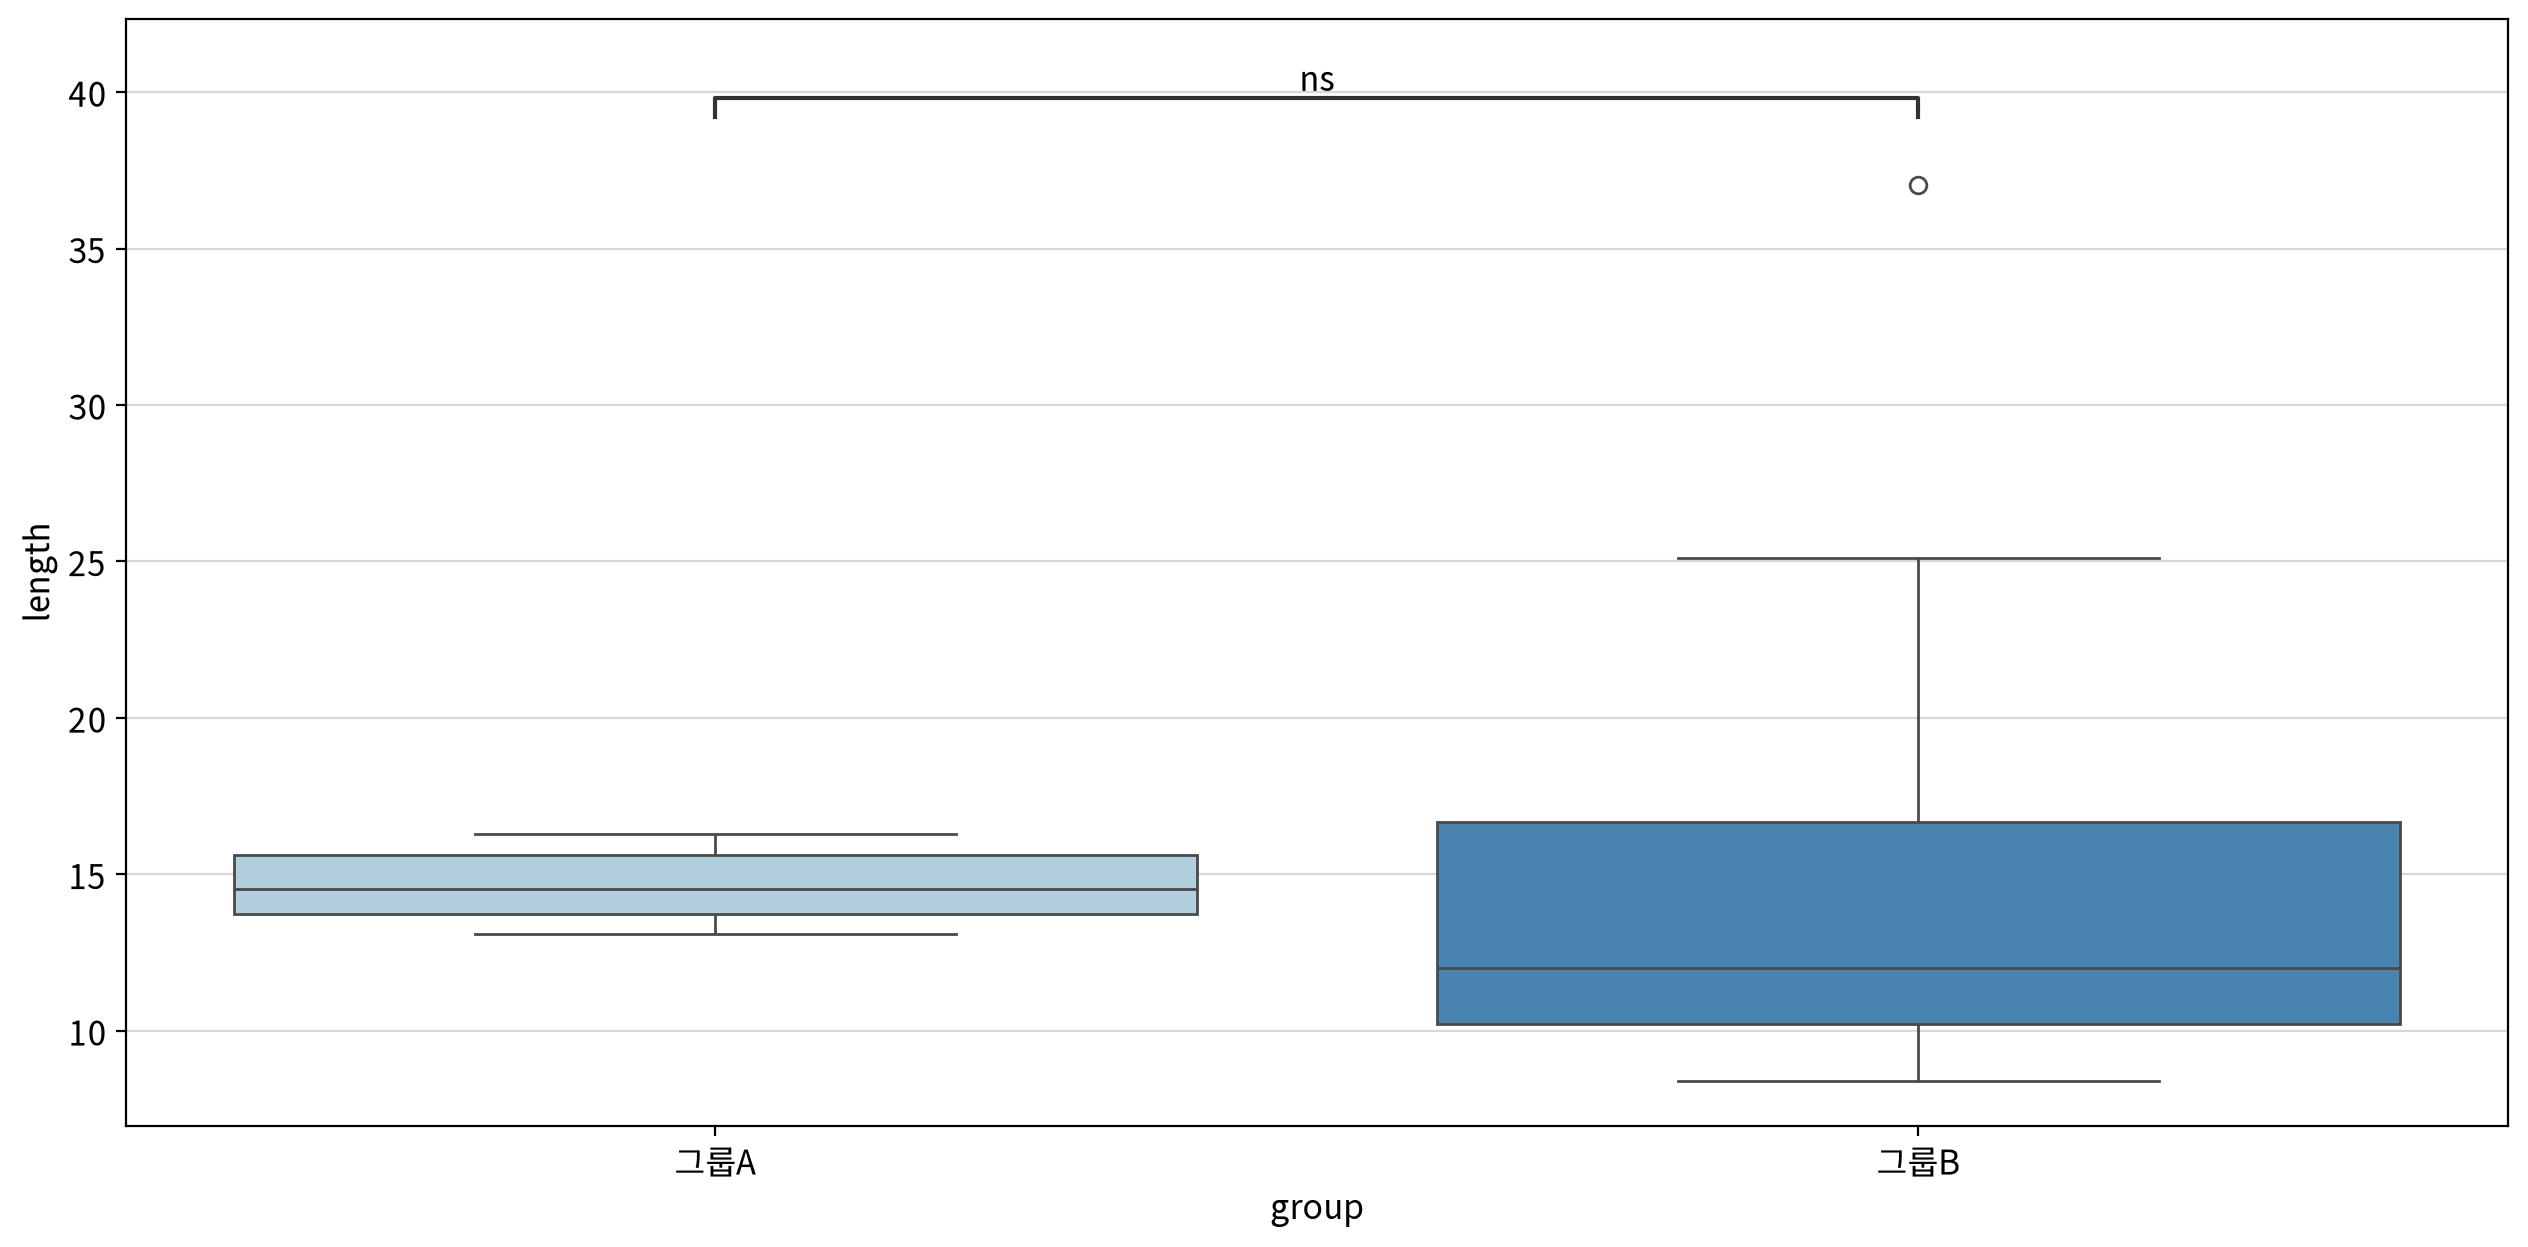

In [19]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df2_melt, 
                x="group", y="length", hue="group", 
                palette="Blues", ax=ax)

# 독립표본 T검정 결과를 시각화에 추가 
annotator = Annotator(data=df2_melt, 
                      x='group', 
                      y='length', 
                      pairs=[('그룹A', '그룹B')], 
                      ax=ax
                      )

# 가설검정 알고리즘 종류 ( 't-test_ind', 't-test_paired', 't-test_welch', 'Mann-Whitney',
# 'Mann-Whitney-gt', 'Mann-Whitney-ls', 'Levene', 'Wilcoxon', 'Kruskal' 등을 지원)

annotator.configure(test='Wilcoxon')
annotator.apply_and_annotate()

my_plot.show()

## #04. 모듈화 기능 확인 

In [20]:
from helpers import my_stats

In [21]:
df1 = load_data("deer")
df1.head()

📚 사슴의 왼쪽 앞다리와 왼쪽 뒷다리의 길이를 측정한 자료 (출처: 방송통신대학교 통계학개론)


,앞다리,뒷다리
사슴,,
1,138,142
2,136,140
3,147,144
4,139,144
5,143,142


### 1. 사슴 다리 길이 비교 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

앞다리 vs. 뒷다리: Wilcoxon test (paired samples), P_val:1.172e-02 Stat=4.000e+00


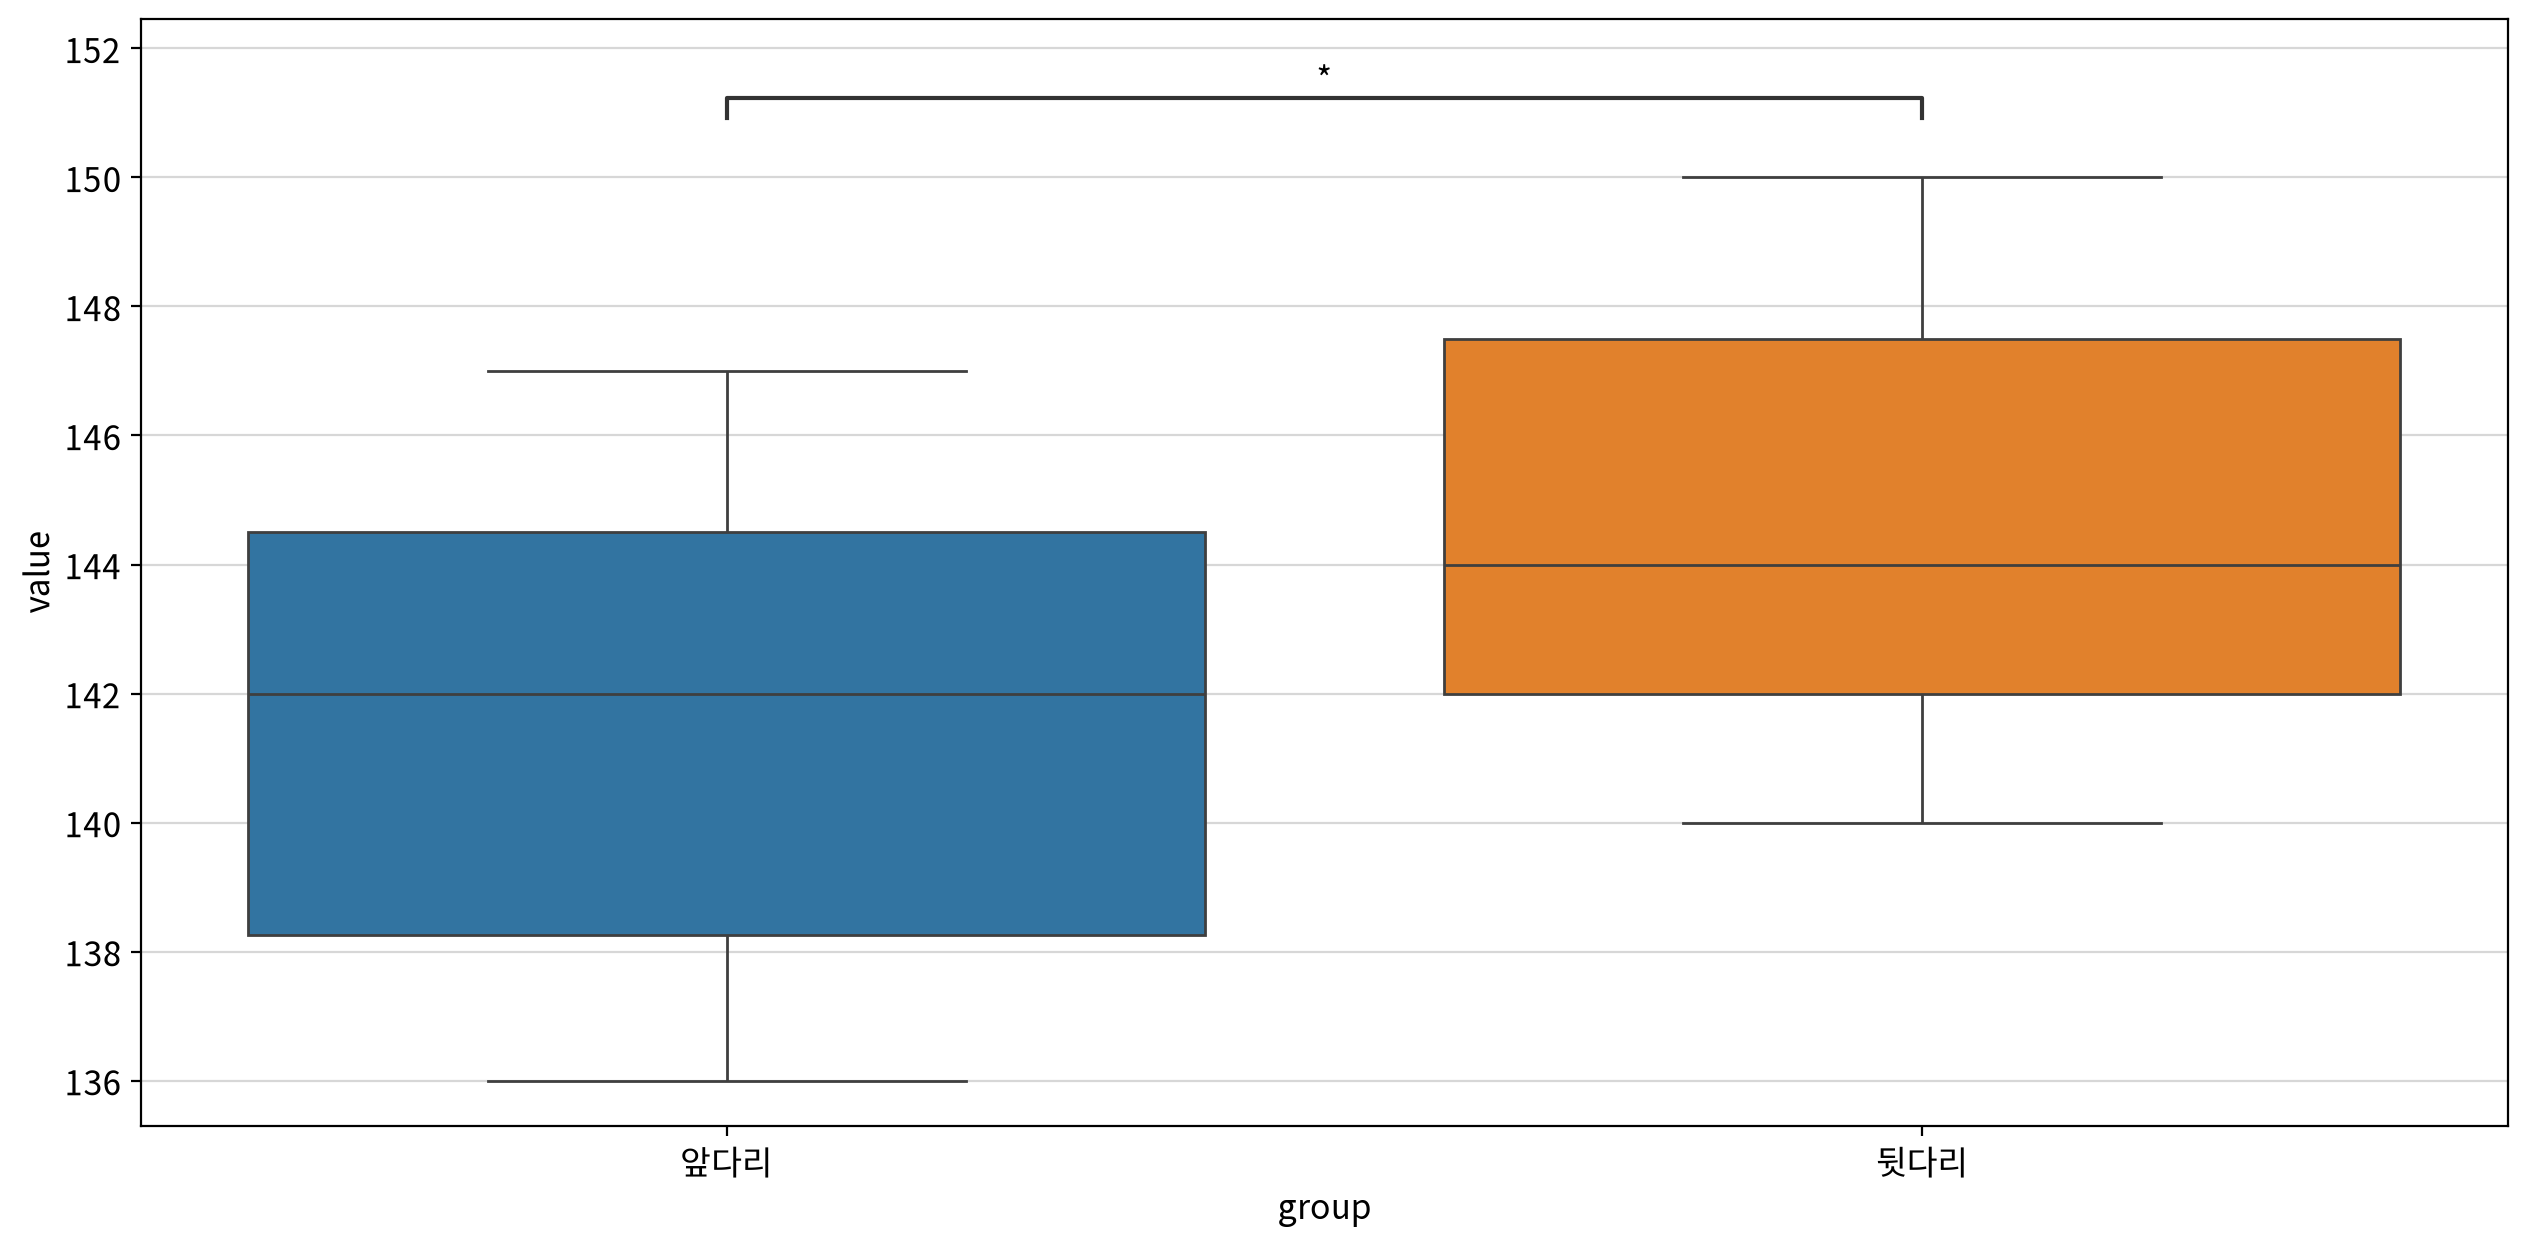

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        4.000    0.012         True   
                          less            51.000    0.995        False   
                          greater         51.000    0.006         True   

                                            result  
test                      alternative               
Wilcoxon signed-rank test two-sided    뒷다리 =/= 앞다리  
                          less          뒷다리 >= 앞다리  
                          greater        뒷다리 > 앞다리

In [22]:
my_stats.test_paired(data=df1, before='앞다리', after='뒷다리')

### 2. 자동차 첨가제가 주행거리에 미치는 영향 

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹A vs. 그룹B: Wilcoxon test (paired samples), P_val:7.695e-01 Stat=2.400e+01


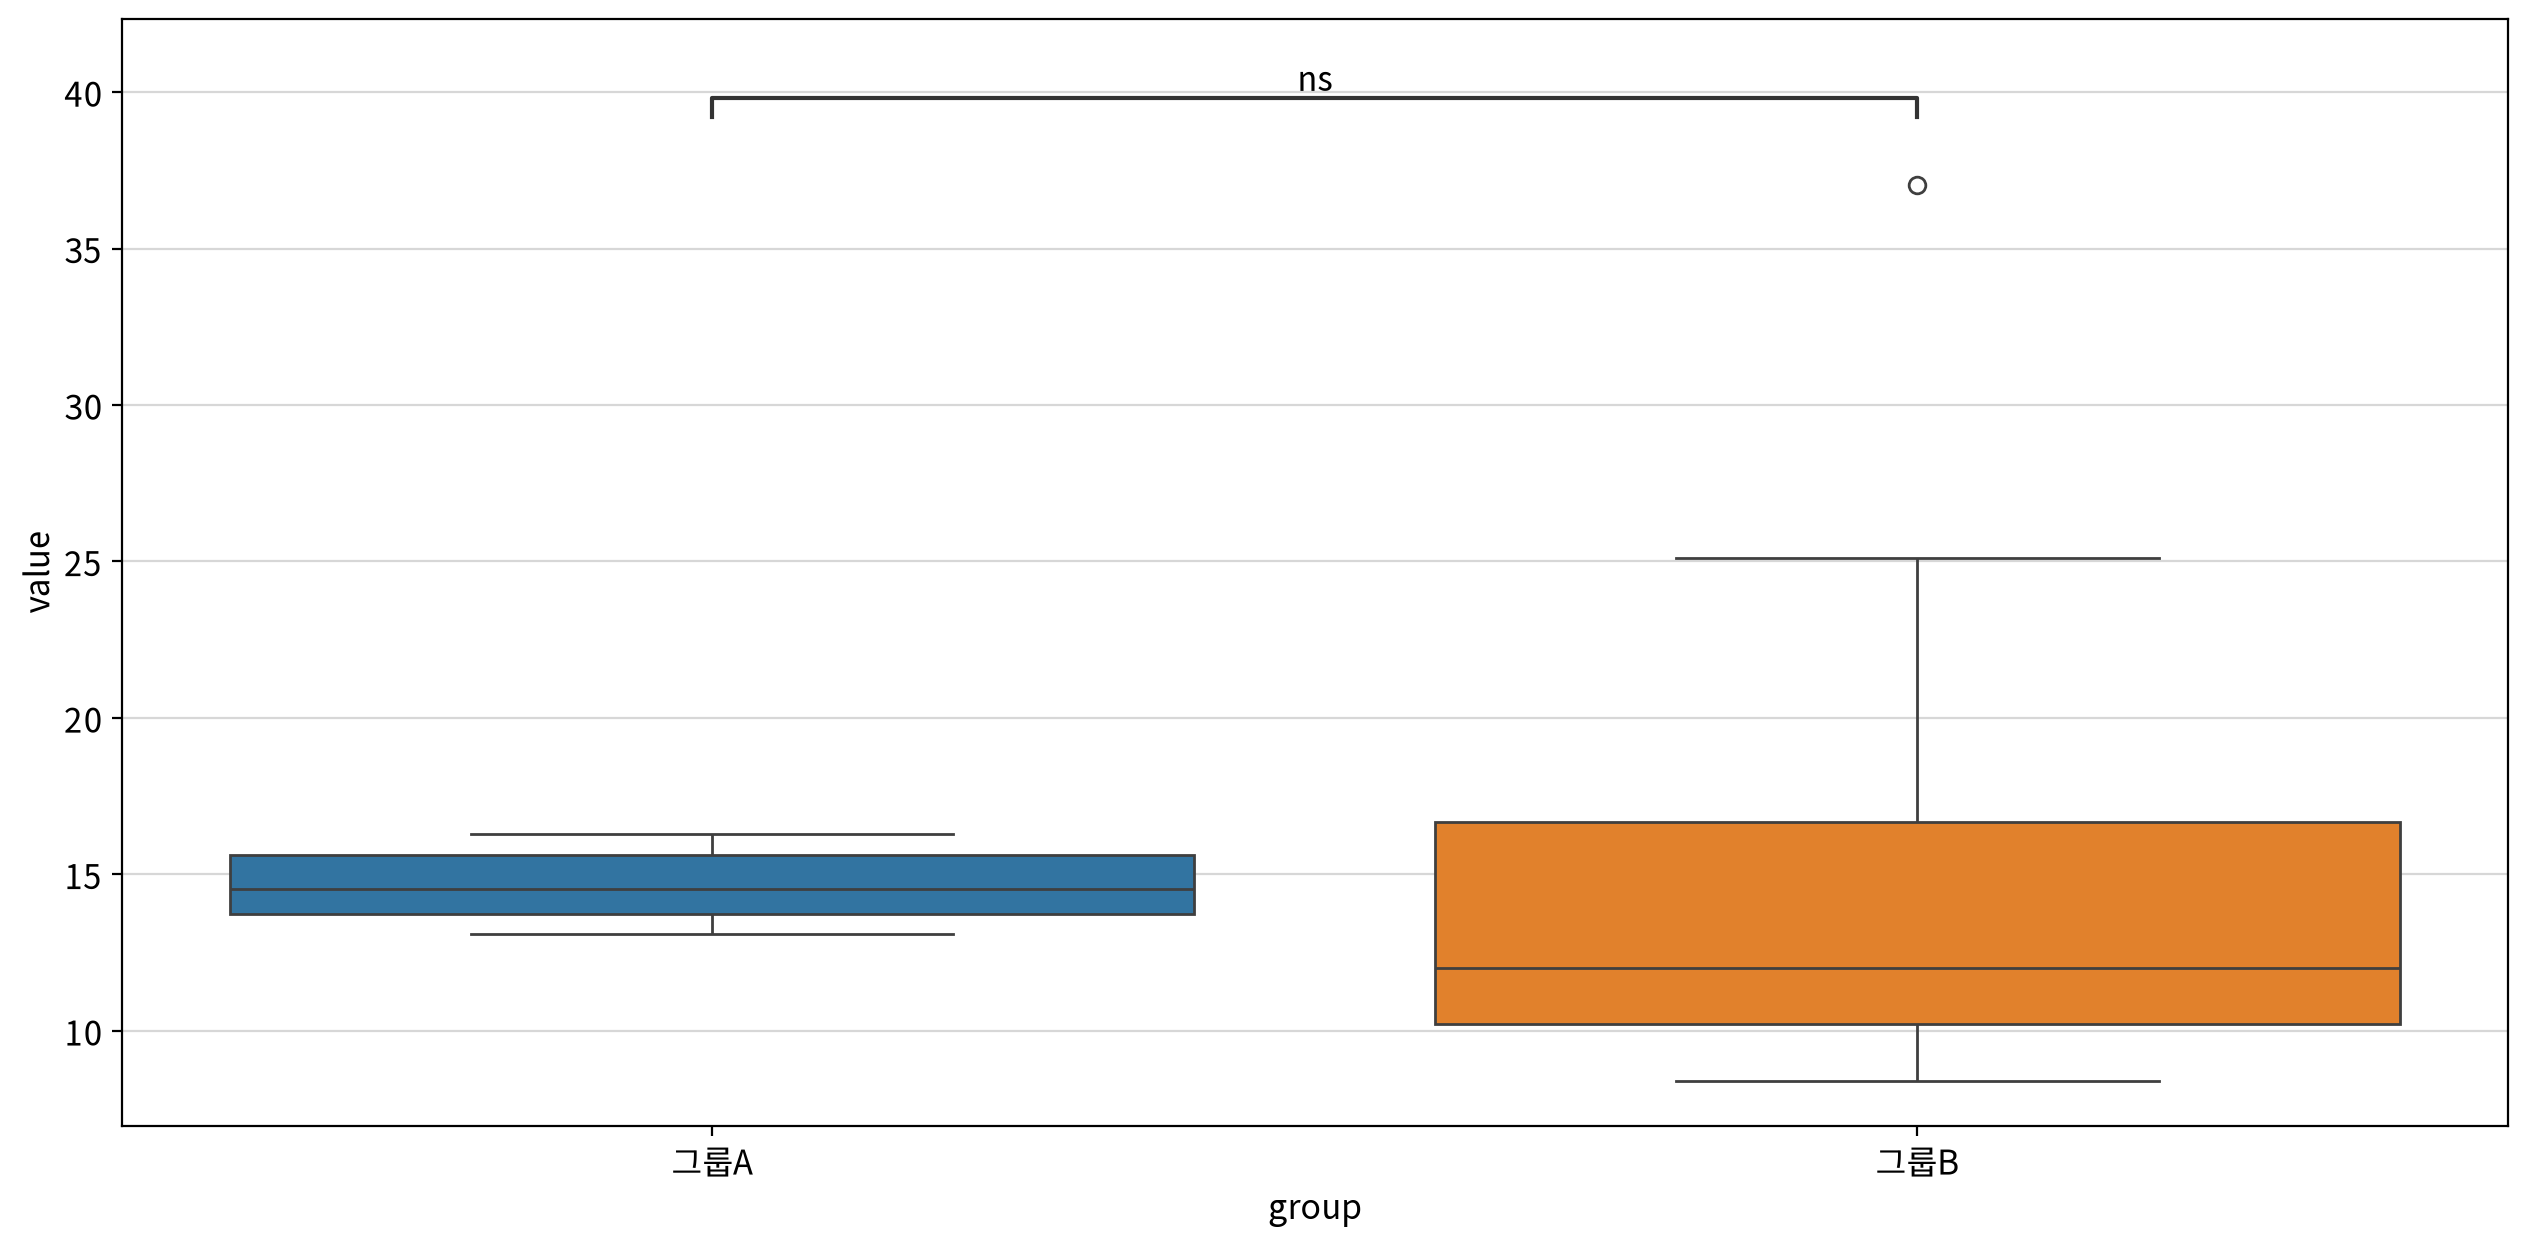

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided       24.000    0.769        False   
                          less            24.000    0.385         True   
                          greater         24.000    0.652        False   

                                           result  
test                      alternative              
Wilcoxon signed-rank test two-sided     그룹B = 그룹A  
                          less          그룹B < 그룹A  
                          greater      그룹B <= 그룹A

In [23]:
my_stats.test_paired(data=df2, before='그룹A', after='그룹B')

In [24]:
from jussam import load_data
from helpers import *

from pandas import pivot_table

## #01. 연습문제 

In [25]:
df = load_data('blood_pressure')
df

📚 부인 15명을 대상으로 평상시 혈압을 측정한 뒤, 이들에게 이 피임약을 일정 기간 복용하게 한 후 이들의 혈압을 다시 측정한 결과를 기록한 데이터 (출처: 방송통신대학교 통계학개론)


,복용전,복용후
0,70,68
1,80,72
2,72,62
3,76,70
4,76,58
5,76,66
6,72,68
7,78,52
8,82,64
9,64,72


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

복용전 vs. 복용후: Wilcoxon test (paired samples), P_val:8.631e-03 Stat=8.000e+00


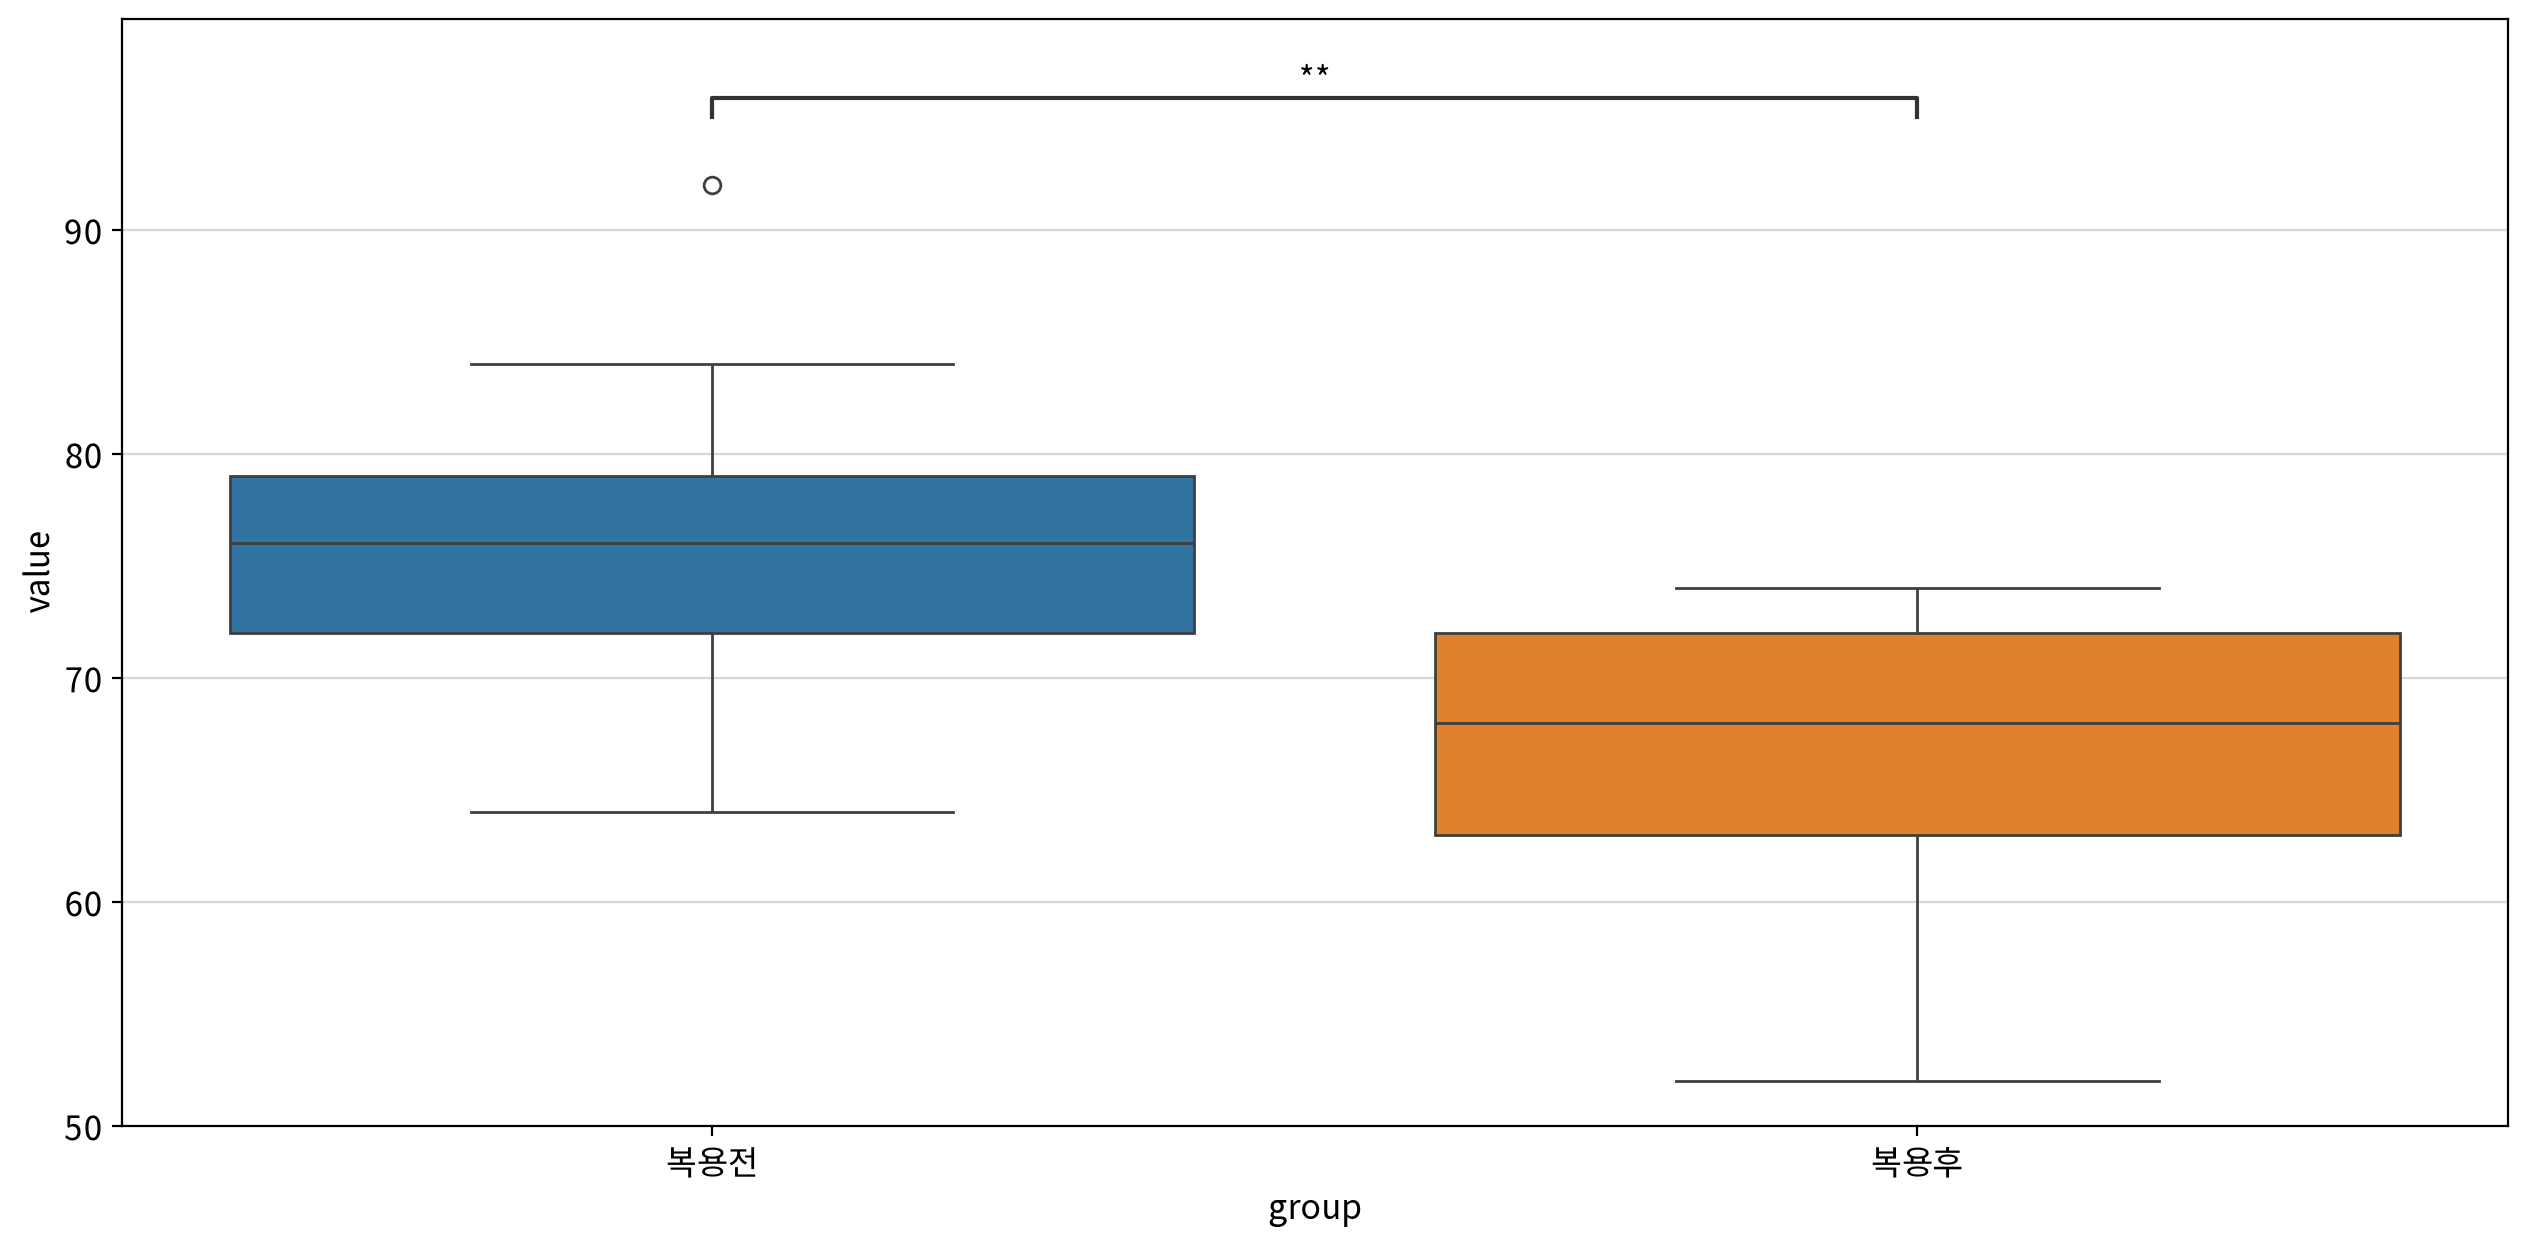

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        8.000    0.009         True   
                          less             8.000    0.004         True   
                          greater          8.000    0.996        False   

                                            result  
test                      alternative               
Wilcoxon signed-rank test two-sided    복용후 =/= 복용전  
                          less           복용후 < 복용전  
                          greater       복용후 <= 복용전

In [26]:
my_stats.test_paired(data=df, before='복용전', after='복용후')

## #02 연습문제 

In [27]:
df = load_data('runner_diet')
df

📚 고등학교 육상선수 10명에게 감량훈련(2~4kg 정도)을 시킨 후 100m 달리기를 실시한 결과를 조사한 데이터 (출처: 방송통신대학교 통계학개론)


,감량전,감량후
0,14.500,14.300
1,13.400,13.400
2,13.000,13.100
3,14.500,13.900
4,13.300,13.100
5,14.200,13.900
6,13.600,13.600
7,13.900,14.000
8,13.200,12.800
9,13.000,12.800


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 vs. 감량후: t-test paired samples, P_val:4.155e-02 t=2.375e+00


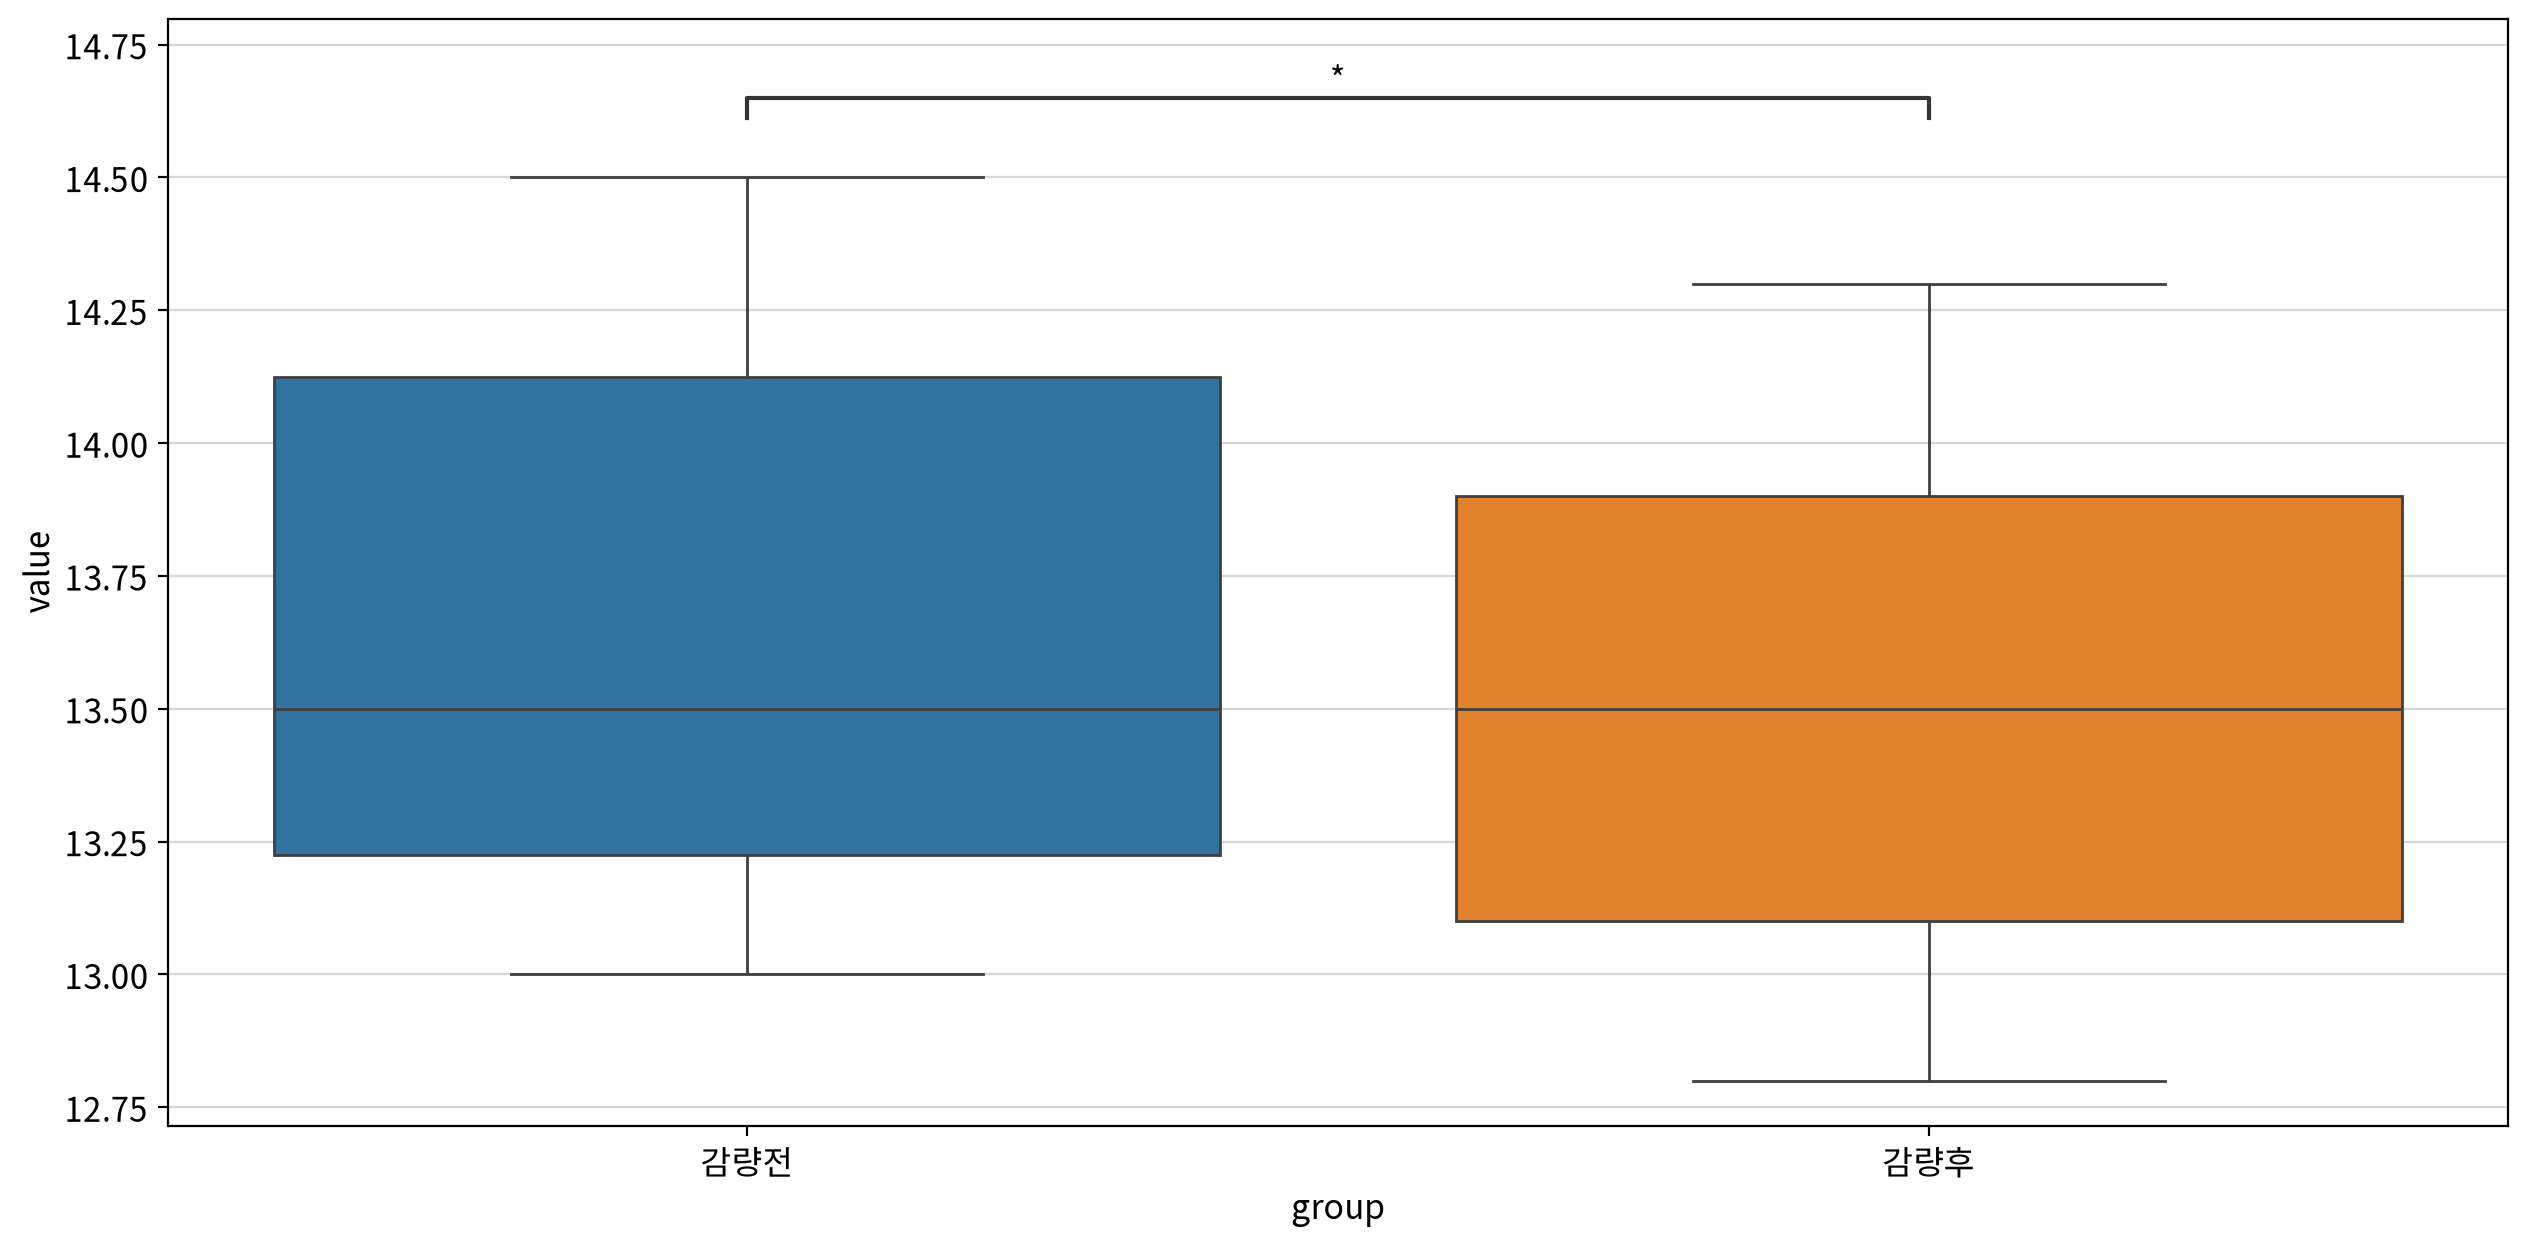

statistic  p-value  significant       result
test          alternative                                              
Paired t-test two-sided       -2.375    0.042         True  감량후 =/= 감량전
              less            -2.375    0.021         True    감량후 < 감량전
              greater         -2.375    0.979        False   감량후 <= 감량전

In [28]:
my_stats.test_paired(data=df, before='감량전', after='감량후')

## #03 연습문제 

In [29]:
df = load_data('wrestler_diet')
df

📚 고등학교 레슬링 선수에게 체중감량을 시키면 체력에 어떤 변화가 일어나는지 조사하기 위하여, 어느 고등학교의 레슬링 선수 12명을 표본추출하여 감량시킨 후 얻은 데이터 (출처: 방송통신대학교 통계학개론)


,이름,감량전 악력,감량후 악력,감량전 윗몸일으키기,감량후 윗몸일으키기,감량전 턱걸이,감량후 턱걸이
0,B.S,43,41,35,41,25,29
1,P.J,42,41,40,44,25,29
2,G.G,52,50,36,41,22,23
3,A.L,53,52,38,42,10,15
4,I.H,44,40,36,42,15,19
5,B.Y,46,47,39,44,17,19
6,I.K,48,47,35,42,24,26
7,K.B,58,55,34,36,17,18
8,K.J,50,50,33,35,17,20
9,S.S,48,50,39,45,21,25


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 악력 vs. 감량후 악력: Wilcoxon test (paired samples), P_val:3.516e-02 Stat=9.000e+00


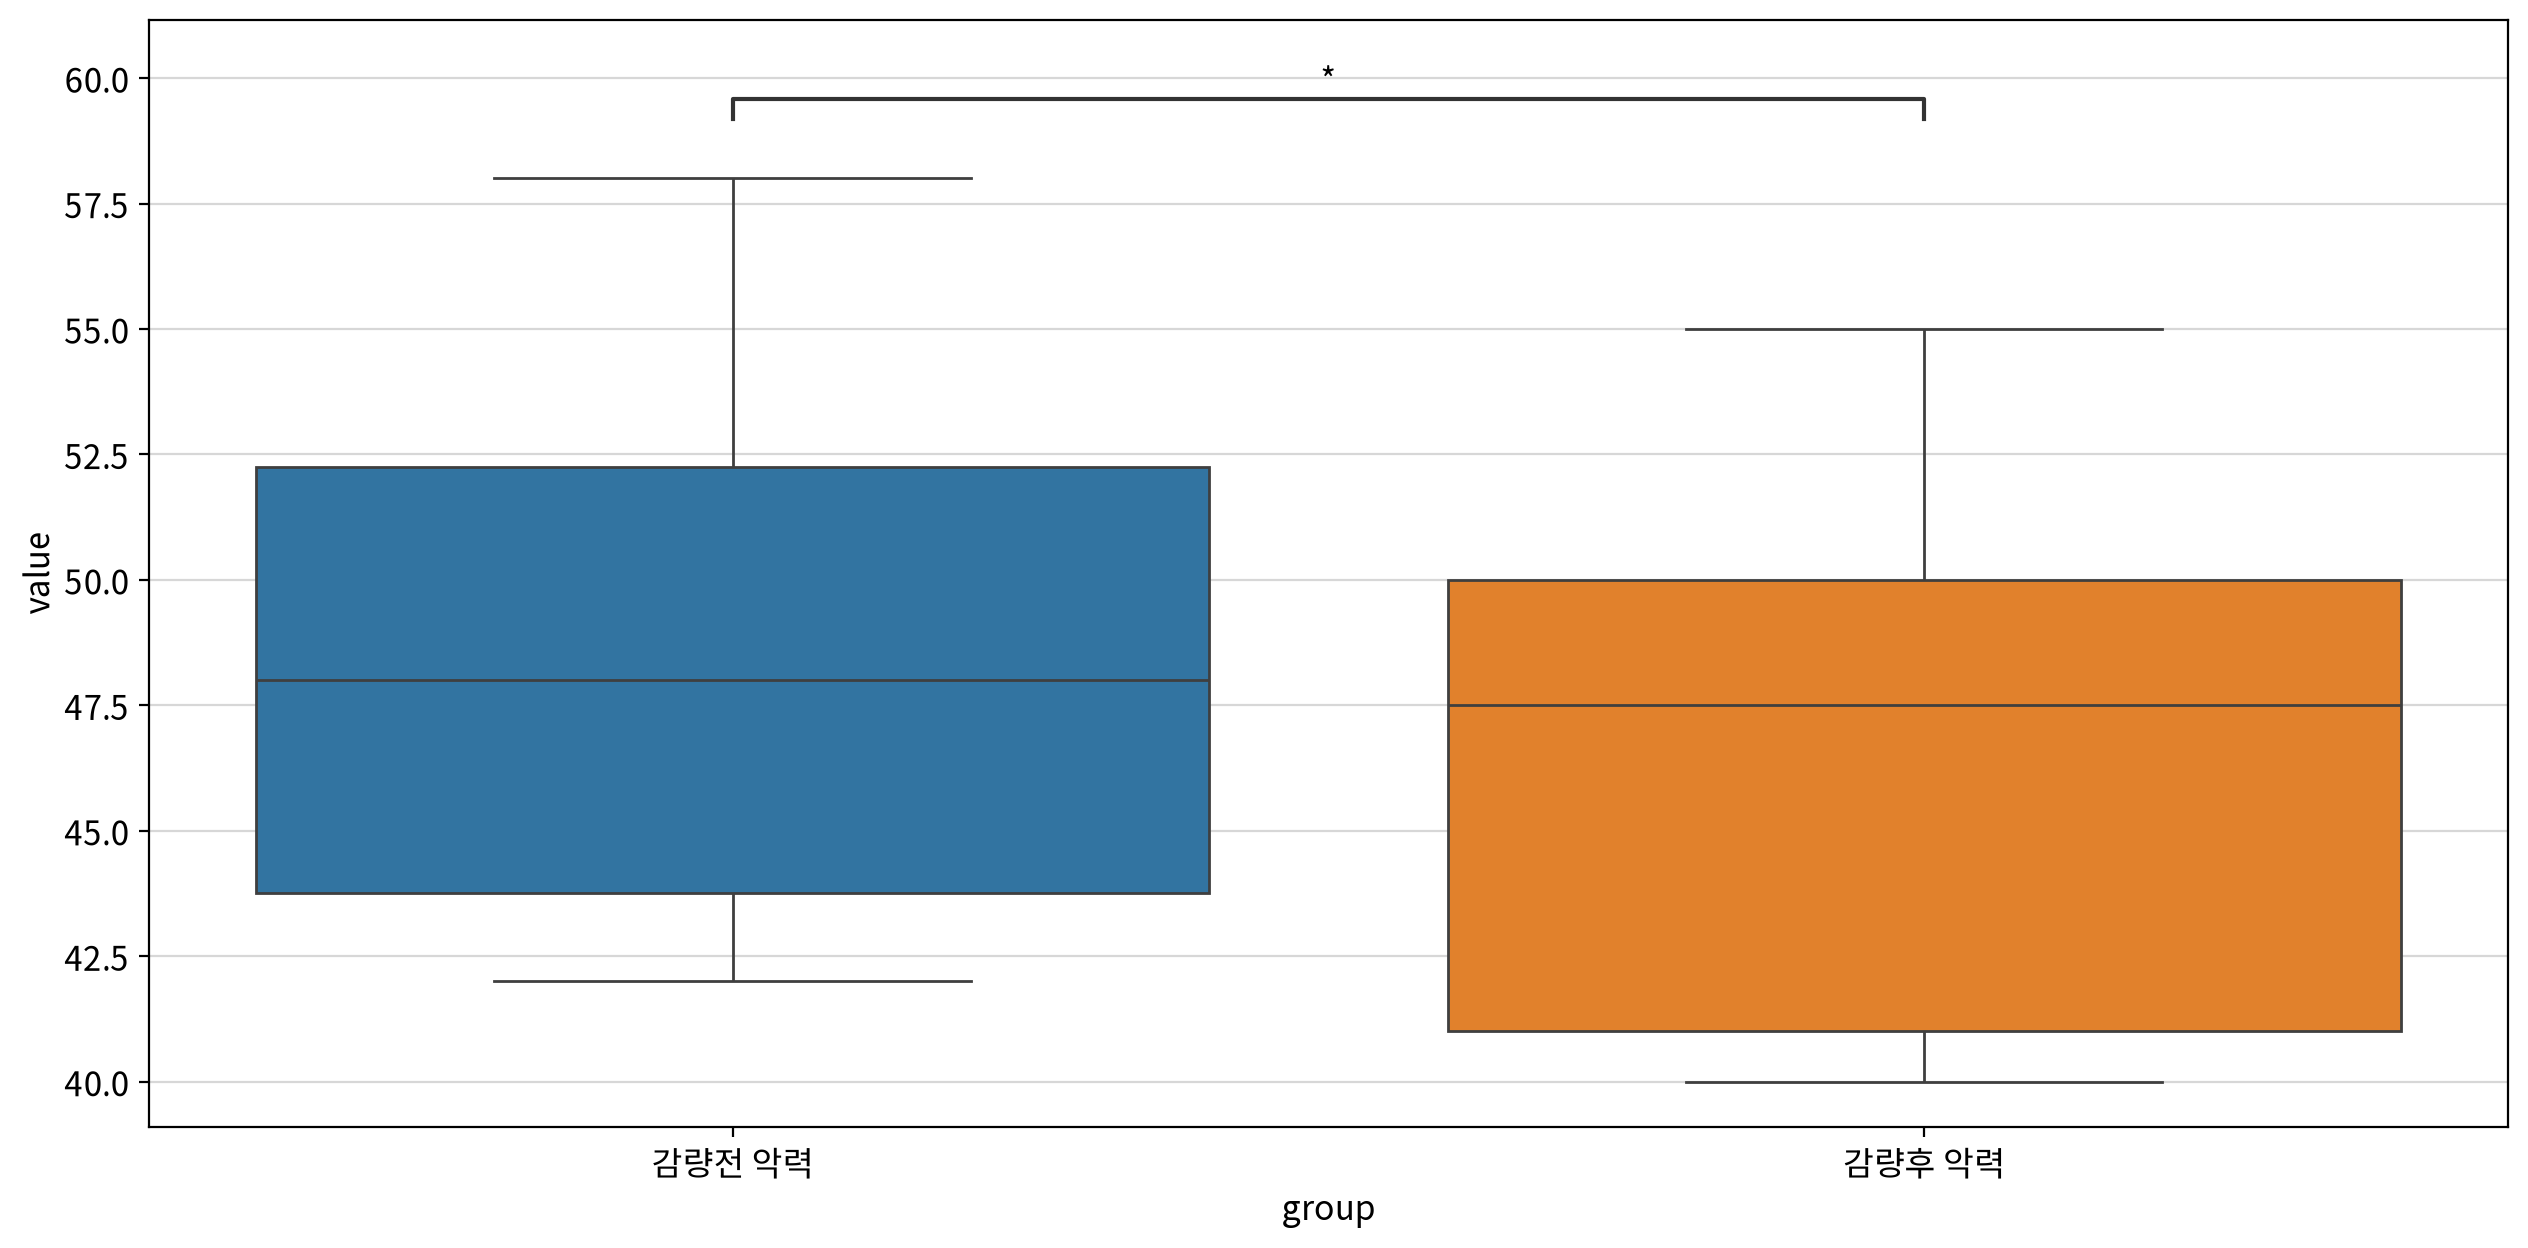

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        9.000    0.035         True   
                          less             9.000    0.018         True   
                          greater          9.000    0.991        False   

                                                  result  
test                      alternative                     
Wilcoxon signed-rank test two-sided    감량후 악력 =/= 감량전 악력  
                          less           감량후 악력 < 감량전 악력  
                          greater       감량후 악력 <= 감량전 악력

In [30]:
my_stats.test_paired(data=df, before='감량전 악력', after='감량후 악력')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 악력 vs. 감량후 악력: Wilcoxon test (paired samples), P_val:3.516e-02 Stat=9.000e+00


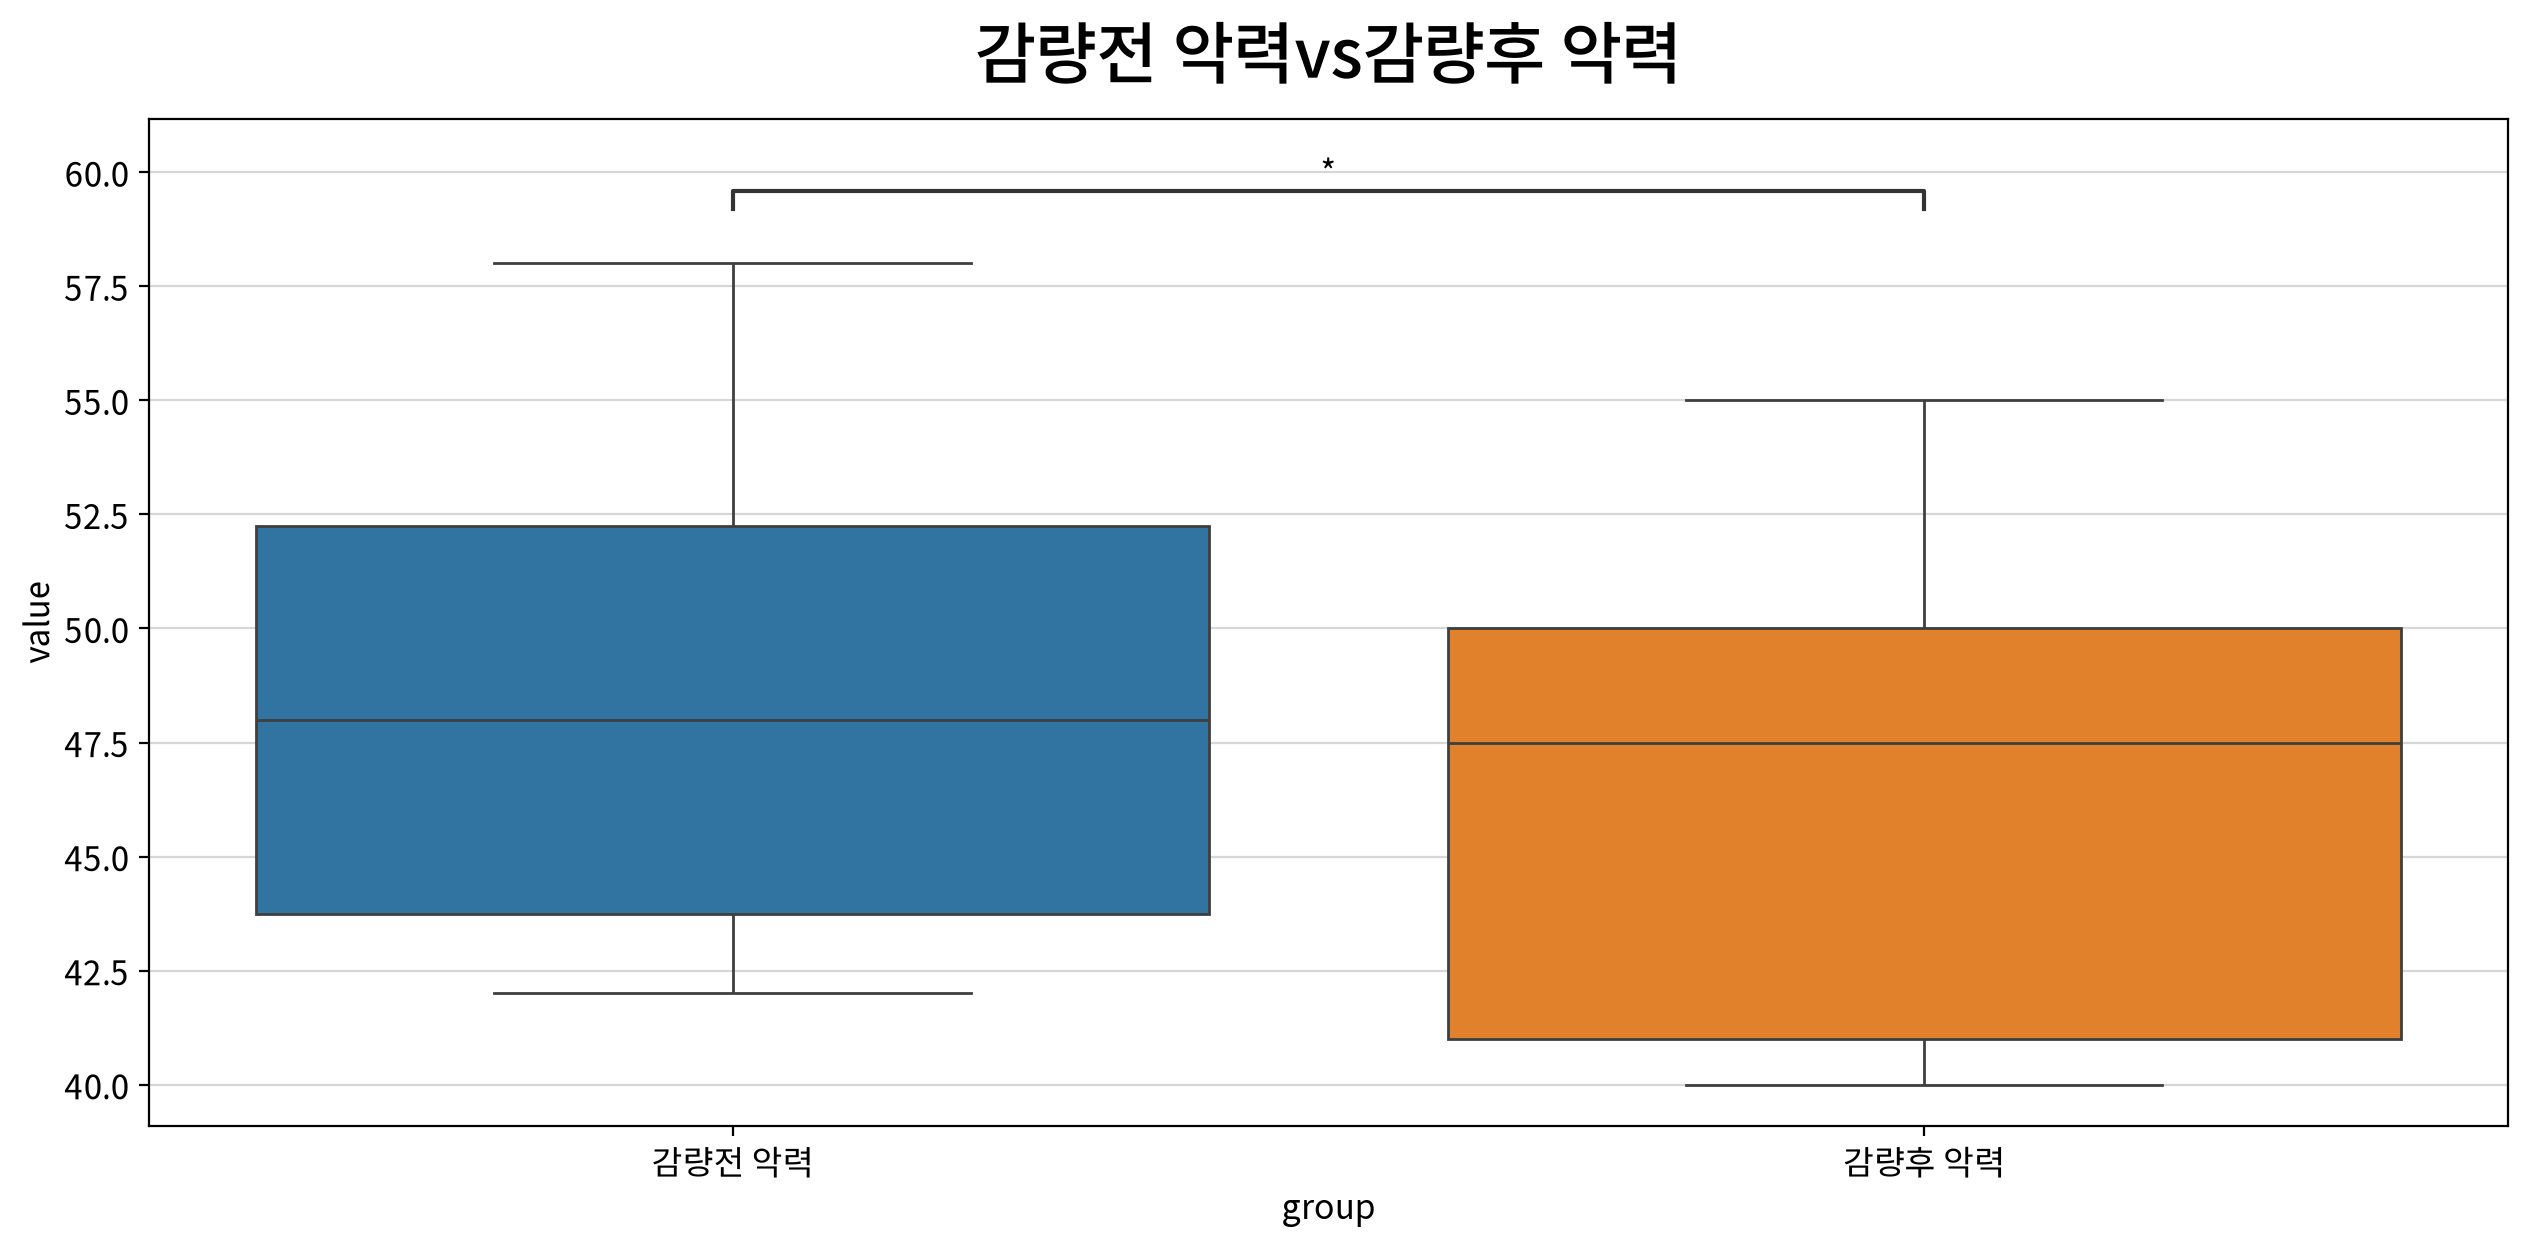

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        9.000    0.035         True   
                          less             9.000    0.018         True   
                          greater          9.000    0.991        False   

                                                  result  
test                      alternative                     
Wilcoxon signed-rank test two-sided    감량후 악력 =/= 감량전 악력  
                          less           감량후 악력 < 감량전 악력  
                          greater       감량후 악력 <= 감량전 악력

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 윗몸일으키기 vs. 감량후 윗몸일으키기: Wilcoxon test (paired samples), P_val:9.766e-04 Stat=0.000e+00


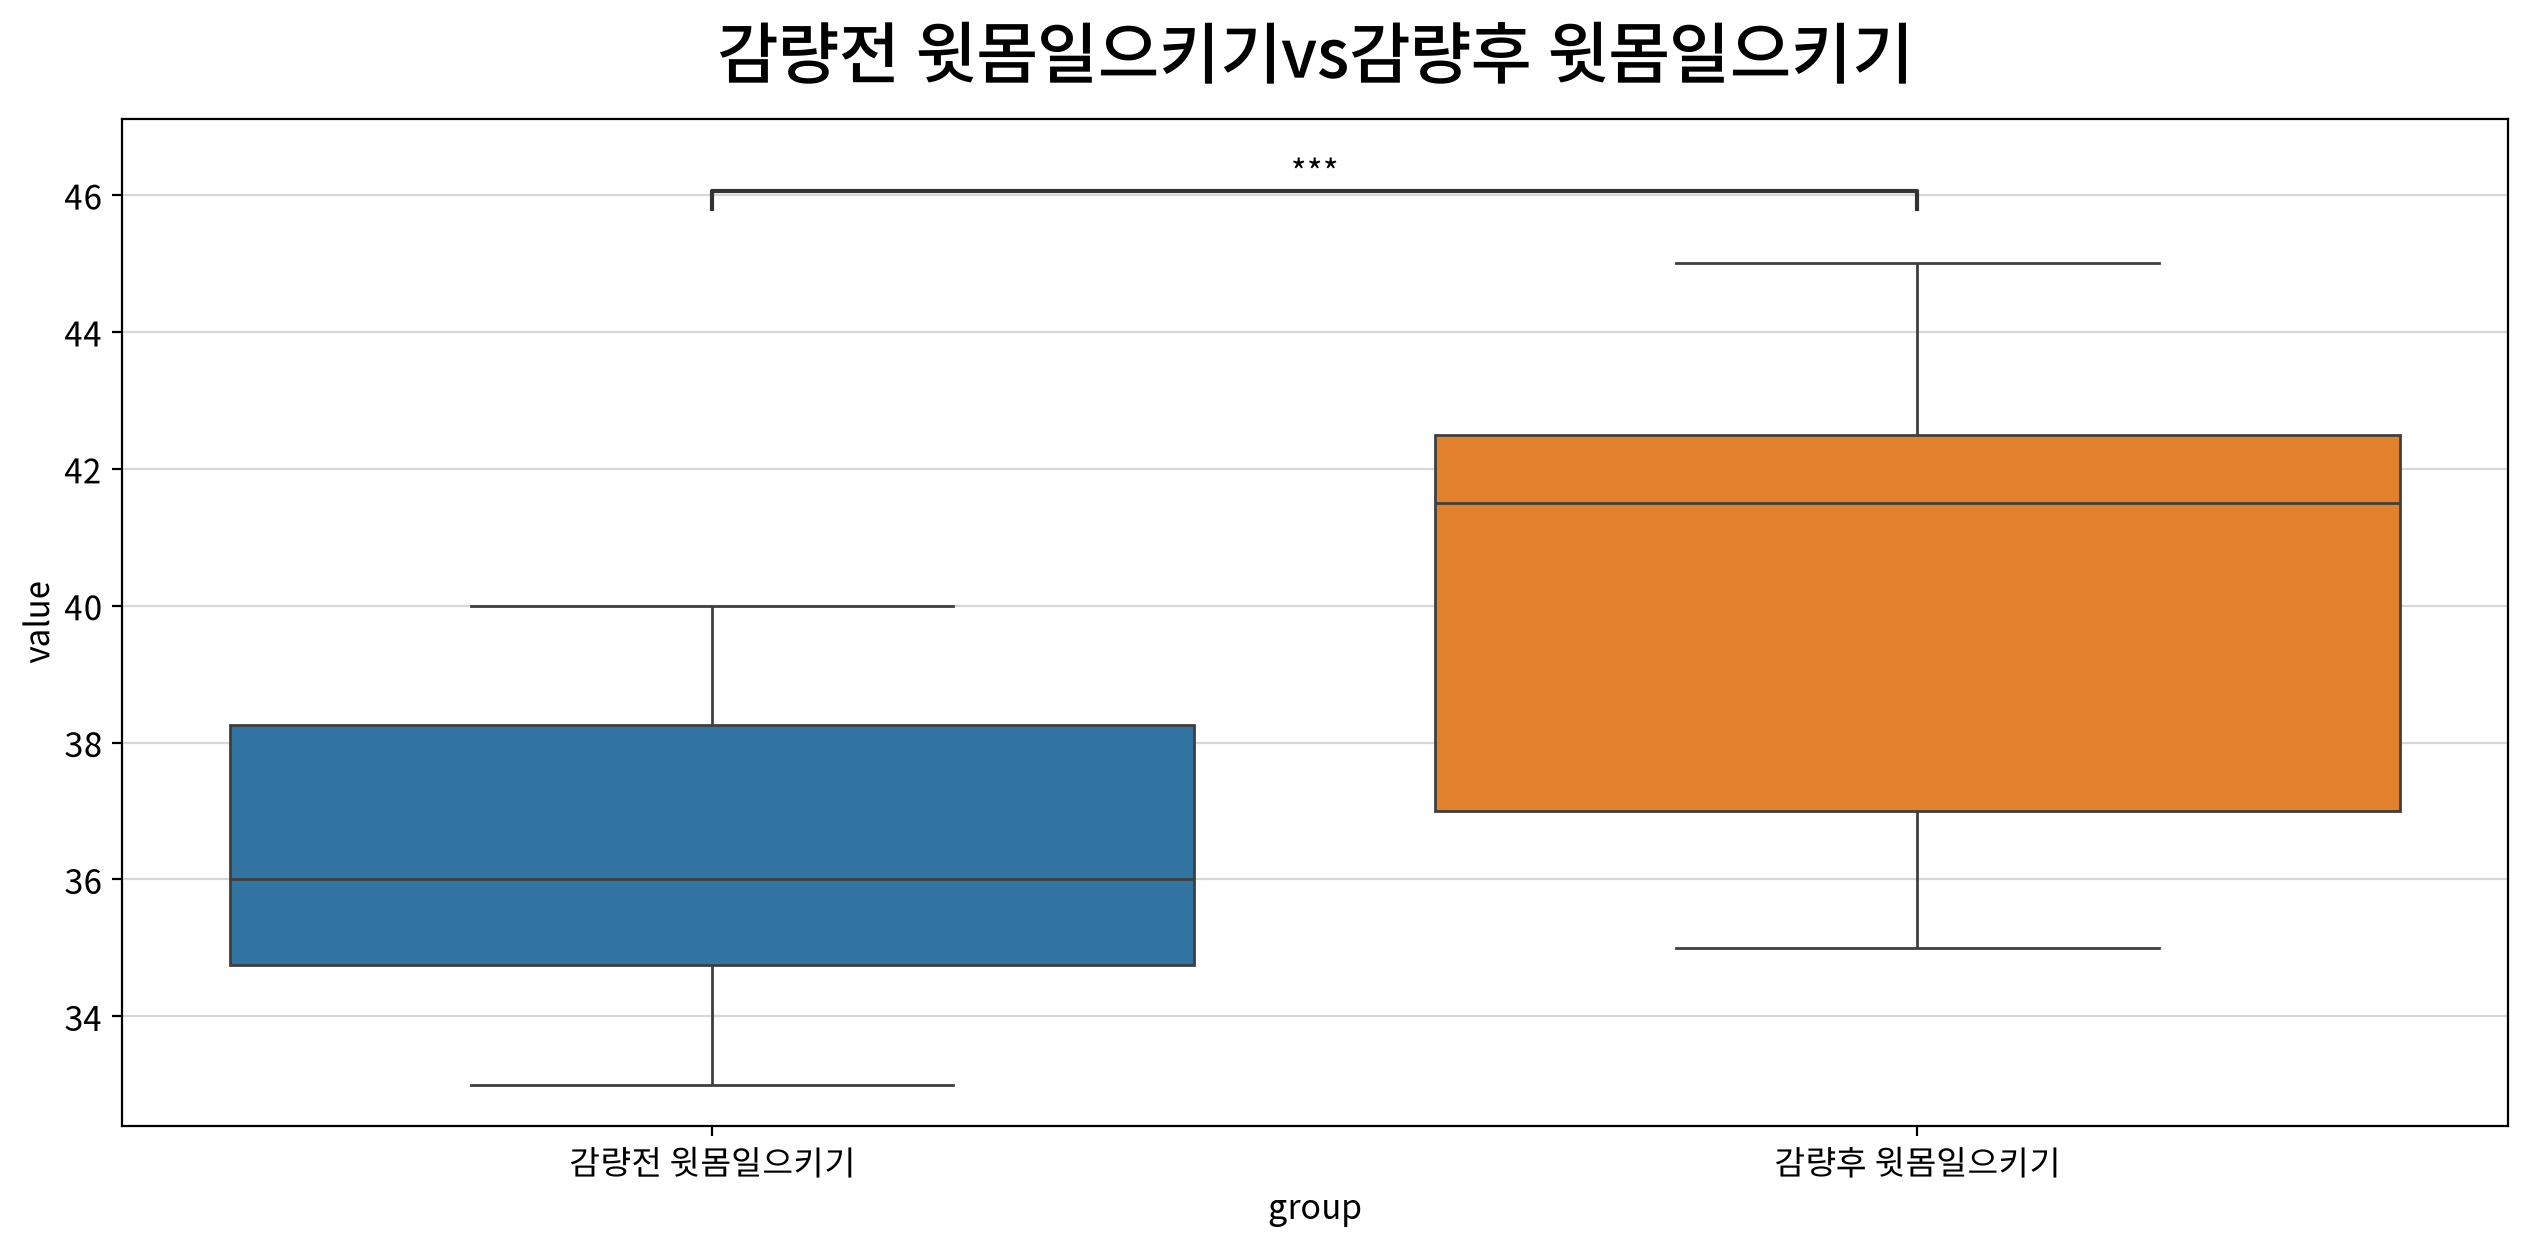

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided        0.000    0.001         True   
                          less            66.000    1.000        False   
                          greater         66.000    0.001         True   

                                                          result  
test                      alternative                             
Wilcoxon signed-rank test two-sided    감량후 윗몸일으키기 =/= 감량전 윗몸일으키기  
                          less          감량후 윗몸일으키기 >= 감량전 윗몸일으키기  
                          greater        감량후 윗몸일으키기 > 감량전 윗몸일으키기

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

감량전 턱걸이 vs. 감량후 턱걸이: t-test paired samples, P_val:2.794e-05 t=-6.842e+00


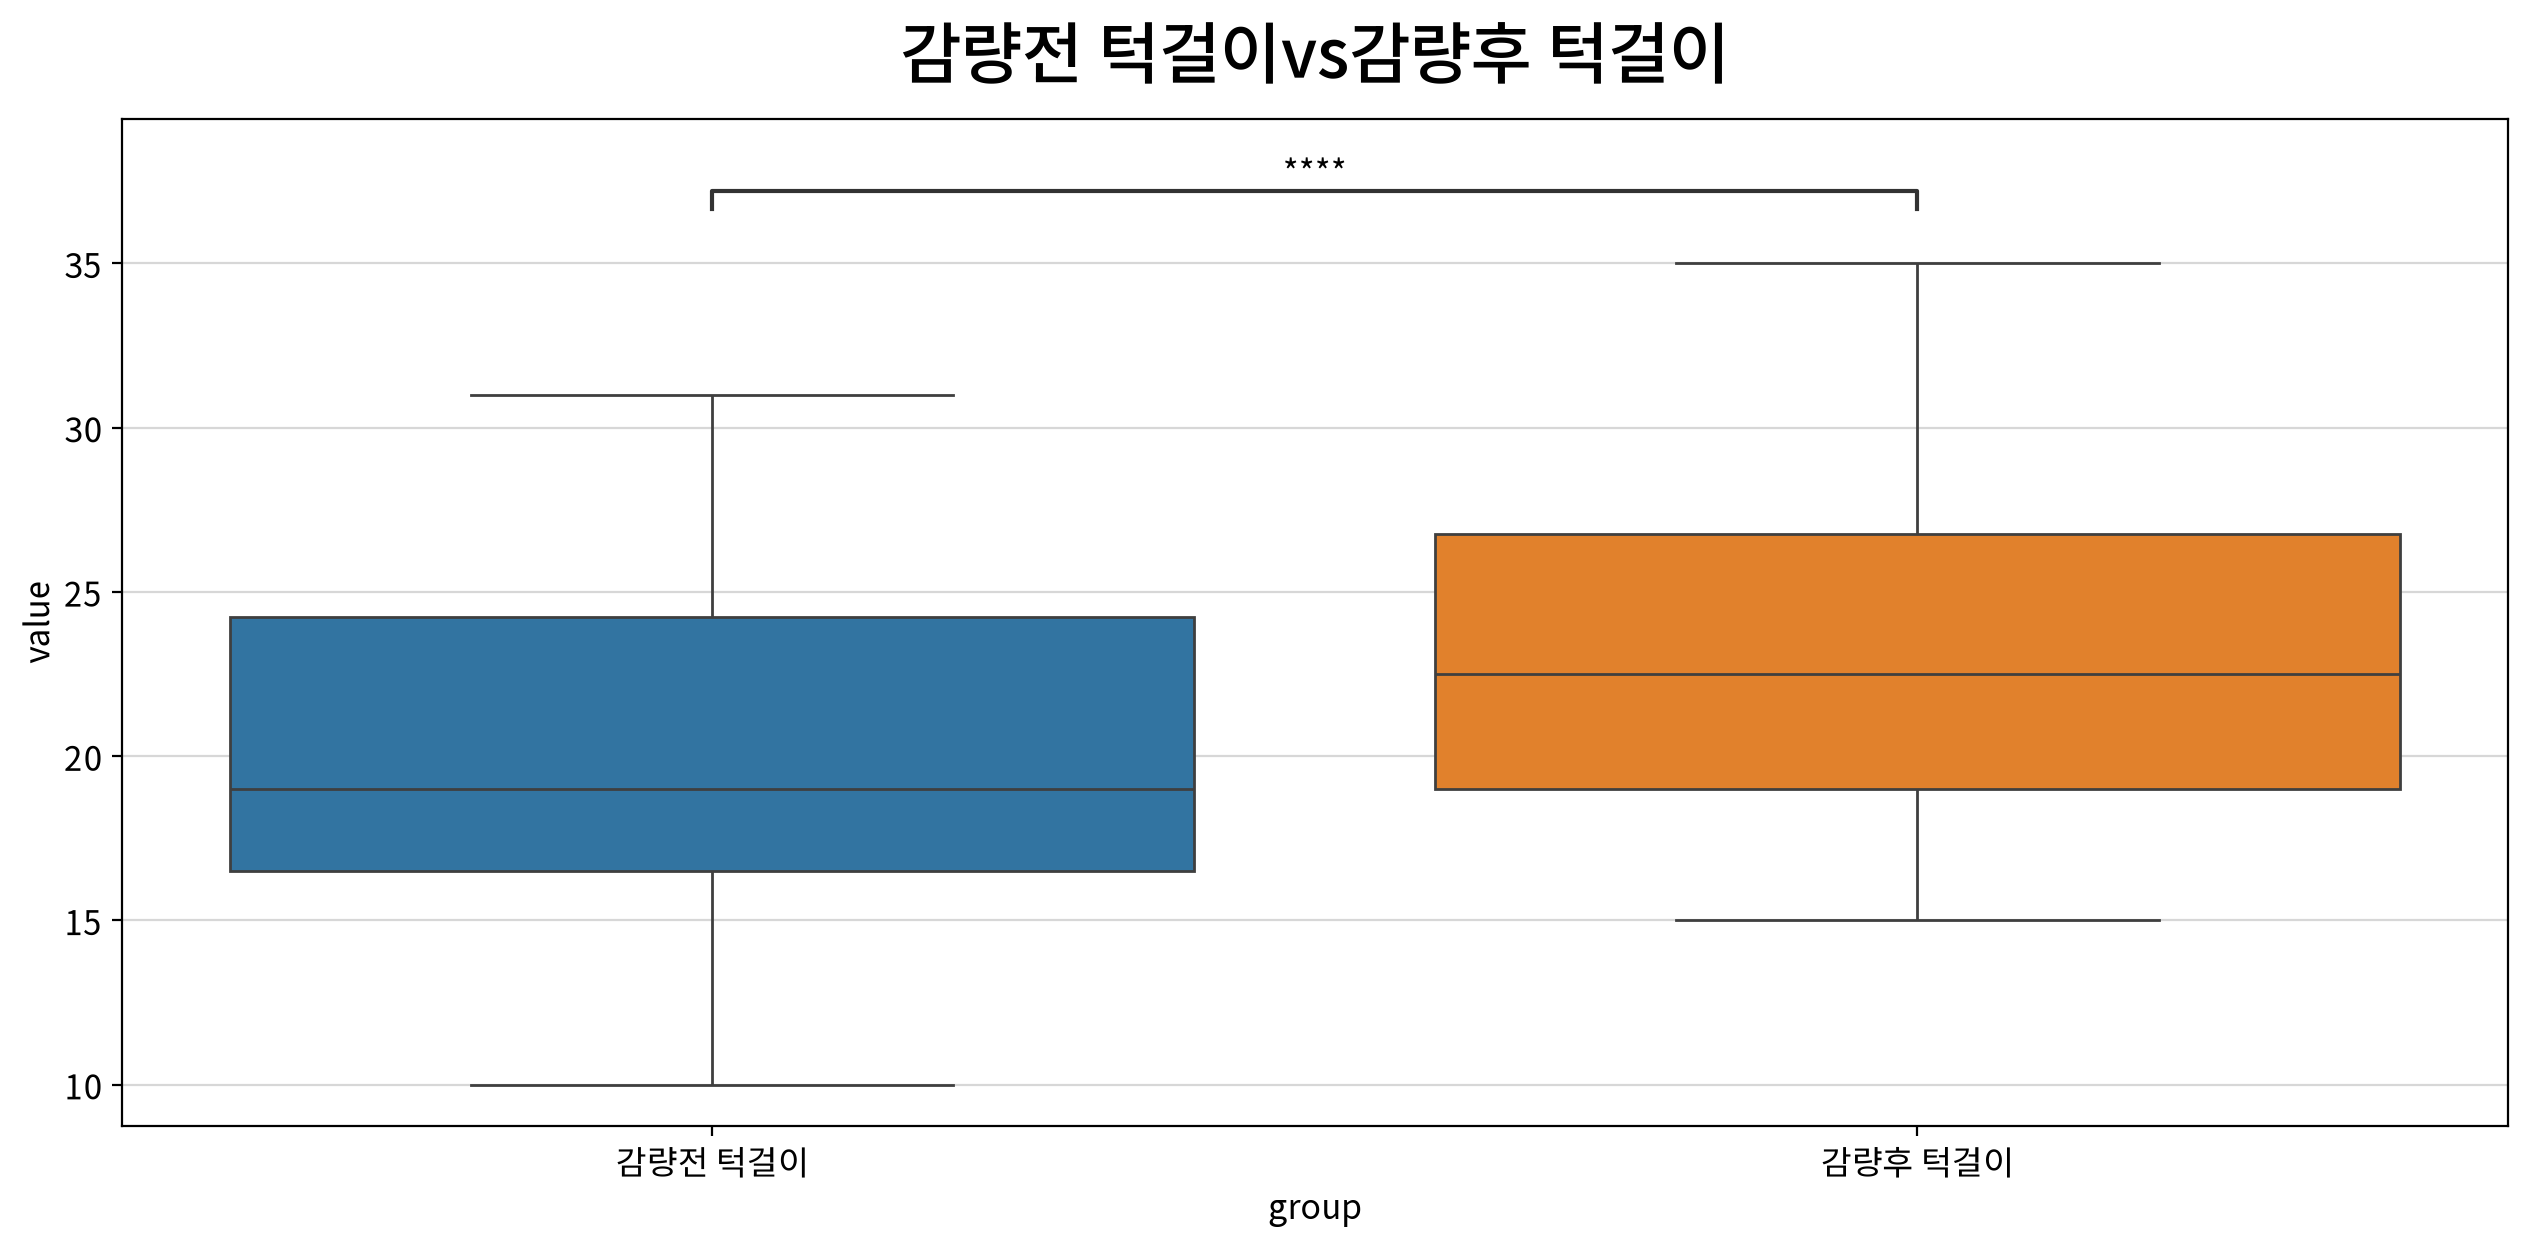

statistic  p-value  significant  \
test          alternative                                    
Paired t-test two-sided        6.842    0.000         True   
              less             6.842    1.000        False   
              greater          6.842    0.000         True   

                                        result  
test          alternative                       
Paired t-test two-sided    감량후 턱걸이 =/= 감량전 턱걸이  
              less          감량후 턱걸이 >= 감량전 턱걸이  
              greater        감량후 턱걸이 > 감량전 턱걸이

In [31]:
# 강사님 코드 
field_group = [['감량전 악력', '감량후 악력'], ['감량전 윗몸일으키기', '감량후 윗몸일으키기'], ['감량전 턱걸이', '감량후 턱걸이']]

for field in field_group:
    result = my_stats.test_paired(df, field[0], field[1], title=field[0] + 'vs' + field[1])
    display(result)

## #04 연습문제 

In [32]:
df4 = load_data("commercial")
df4

📚 서울시의 2023년 상권에 따른 분기별 매출액과 매출건수에 대한 자료 (출처: 서울 열린데이터 광장)


,quarter,code,type,name,sales_amount,number_of_sales
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166
...,...,...,...,...,...,...
6217,4,3130323,전통시장,둔촌역전통시장,13523478306,535132
6218,4,3130324,전통시장,길동복조리시장,6236556030,330148
6219,4,3130325,전통시장,명일전통시장,3973269286,186049
6220,4,3130326,전통시장,고덕 골목형상점가,15013907999,755565


In [33]:
df4.isna().sum()

quarter            0
code               0
type               0
name               0
sales_amount       0
number_of_sales    0
dtype: int64

In [35]:
# 상권 유형 확인 
df4['type'].unique()

<ArrowStringArray>
['관광특구', '골목상권', '발달상권', '전통시장']
Length: 4, dtype: str

In [ ]:
# 상반기( 1, 2분기) / 하반기( 3, 4분기)

In [36]:
# 상/하반기 구분 파생변수 추가 
df4['구분'] = df4['quarter'].map({1:'상반기', 2:'상반기', 3:'하반기', 4:'하반기'})
df4.head()

,quarter,code,type,name,sales_amount,number_of_sales,구분
0,1,3001491,관광특구,이태원 관광특구,72523644100,2496865,상반기
1,1,3001492,관광특구,명동 남대문 북창동 다동 무교동 관광특구,283332346393,10246122,상반기
2,1,3001493,관광특구,동대문패션타운 관광특구,81696730221,2880324,상반기
3,1,3001494,관광특구,종로·청계 관광특구,212062656625,4960006,상반기
4,1,3001495,관광특구,잠실 관광특구,231338386876,5995166,상반기


In [37]:
df5 = df4[df4['type']=='골목상권']
df5

,quarter,code,type,name,sales_amount,number_of_sales,구분
6,1,3110001,골목상권,이북5도청사,435264344,13080,상반기
7,1,3110002,골목상권,독립문역 1번,4062721649,339647,상반기
8,1,3110003,골목상권,세검정초등학교,576819152,16978,상반기
9,1,3110004,골목상권,대신고등학교,312840339,7706,상반기
10,1,3110005,골목상권,세검정,666679997,10162,상반기
...,...,...,...,...,...,...,...
5690,4,3111086,골목상권,한영중고,4733024545,196999,하반기
5691,4,3111087,골목상권,고덕중학교(고덕2동주민센터),1644486933,65056,하반기
5692,4,3111088,골목상권,고덕동성당,2953618538,158690,하반기
5693,4,3111089,골목상권,상일여고(상일초등학교),12713570299,430385,하반기


In [38]:
df6 = pivot_table(df5, index='code', columns='구분', values='sales_amount')
df6

구분,상반기,하반기
code,,
3110001,579794482.500,660232165.500
3110002,5324165915.000,7225755615.000
3110003,816834877.500,971411239.000
3110004,378617224.500,398747715.000
3110005,738929894.500,808203808.500
...,...,...
3111086,4052571592.500,4855904004.500
3111087,1315713158.000,1482799081.000
3111088,3188667005.500,2945983841.500


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

상반기 vs. 하반기: Wilcoxon test (paired samples), P_val:1.590e-94 Stat=6.624e+04


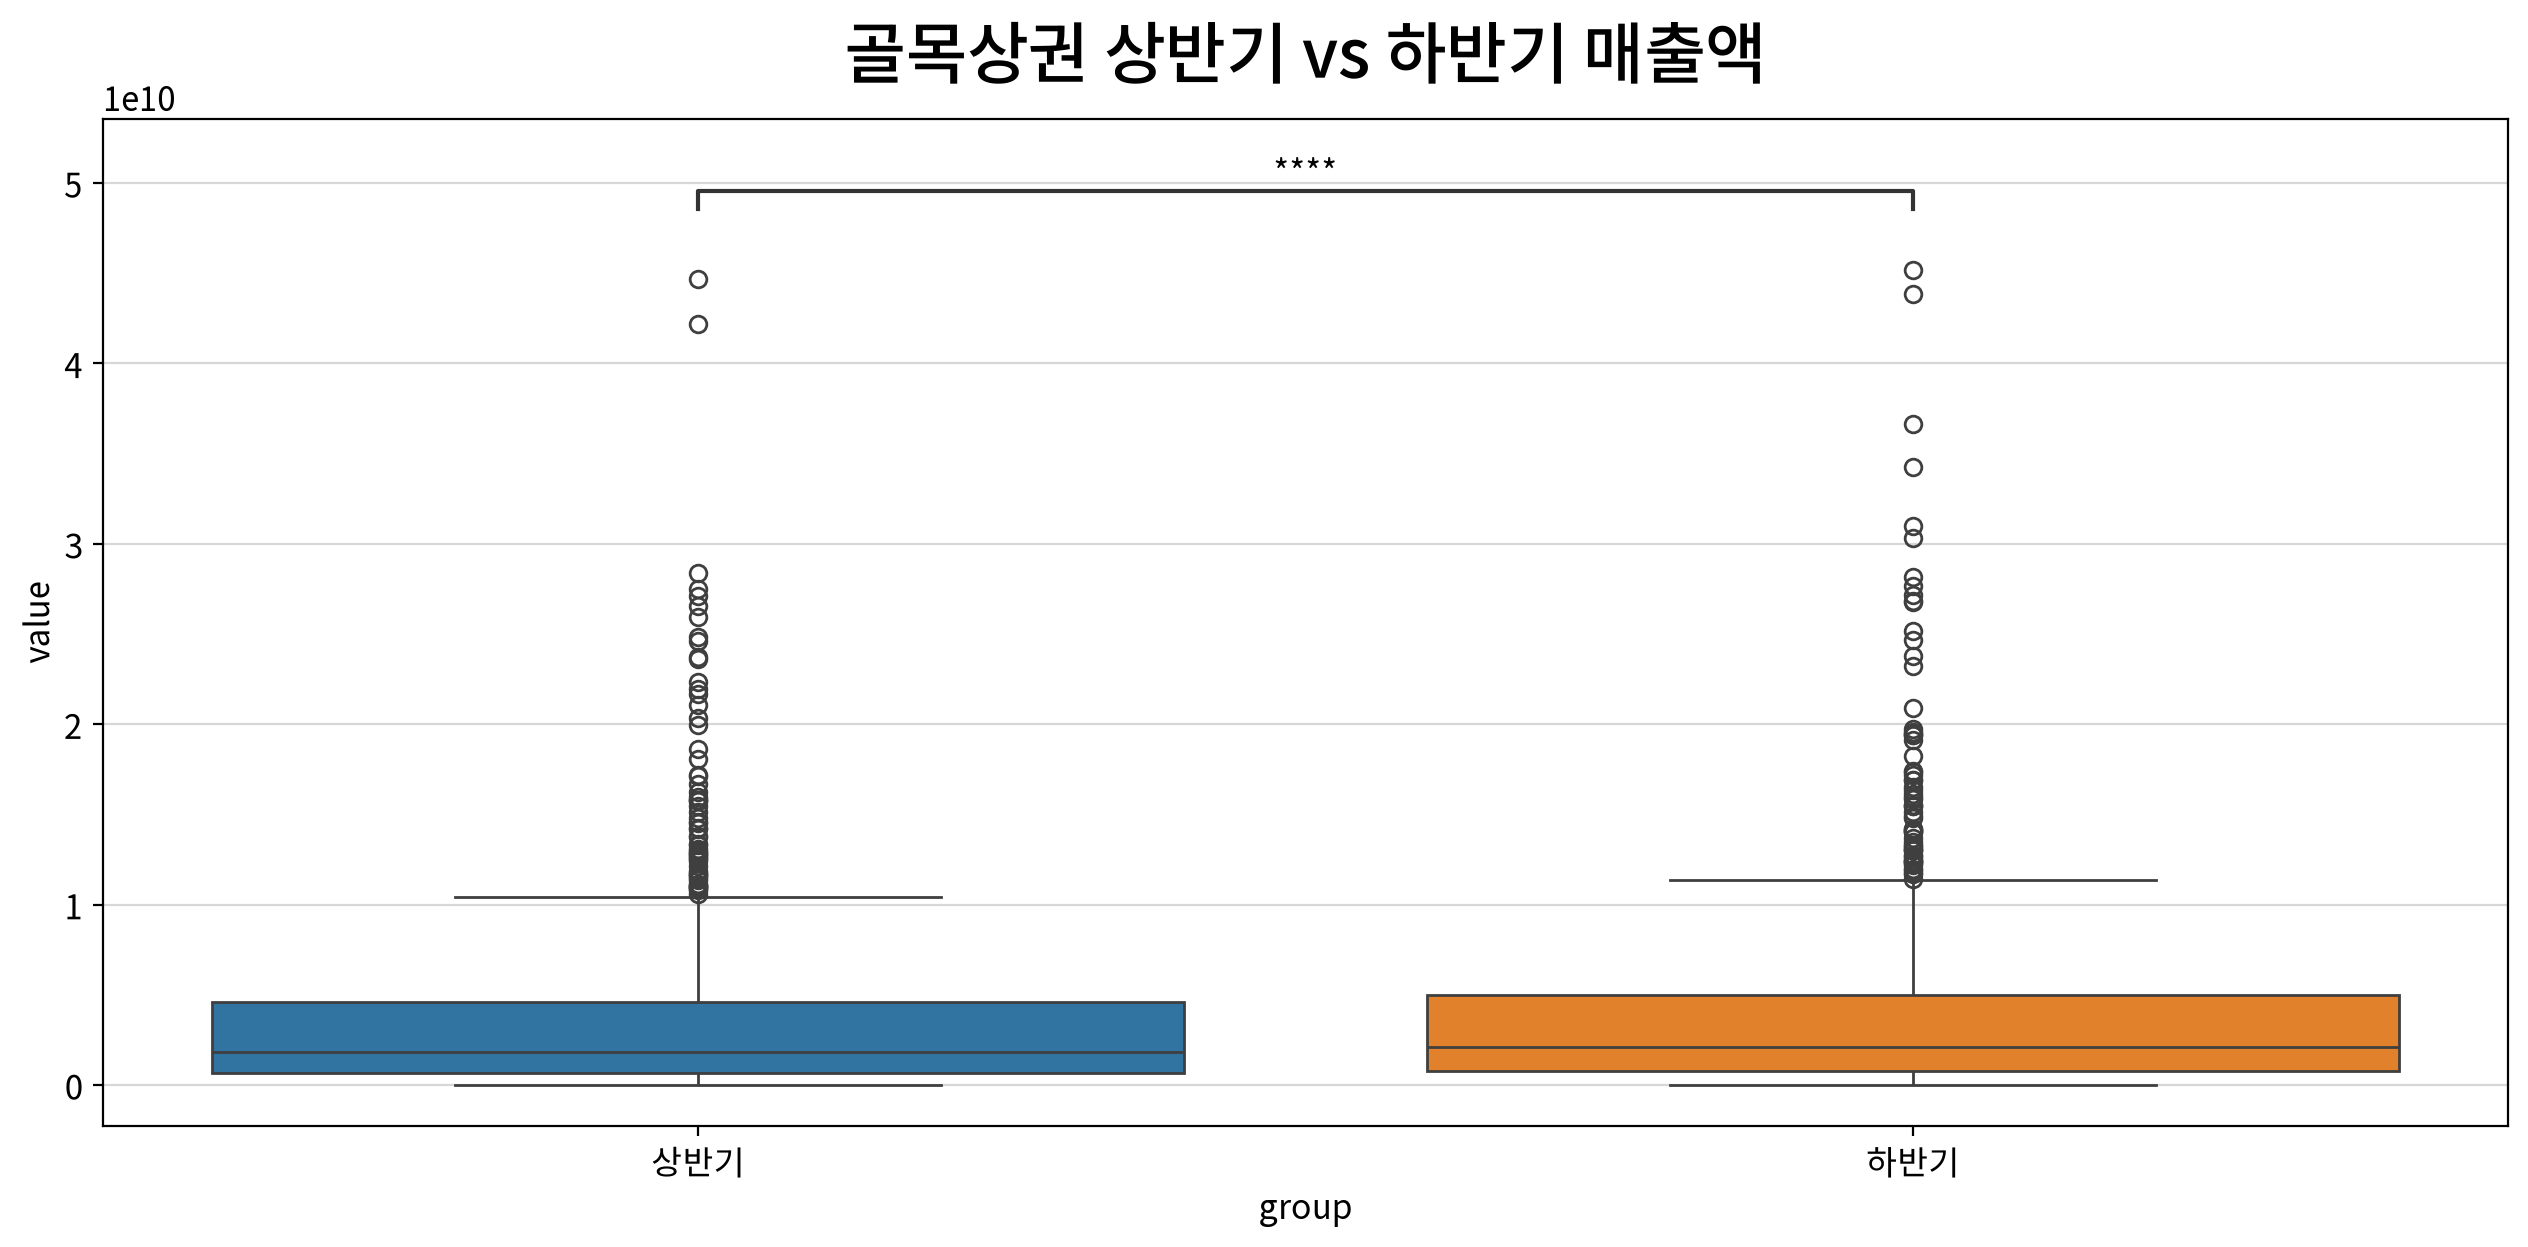

statistic  p-value  significant  \
test                      alternative                                    
Wilcoxon signed-rank test two-sided    66243.000    0.000         True   
                          less        454467.000    1.000        False   
                          greater     454467.000    0.000         True   

                                            result  
test                      alternative               
Wilcoxon signed-rank test two-sided    하반기 =/= 상반기  
                          less          하반기 >= 상반기  
                          greater        하반기 > 상반기

In [ ]:
my_stats.test_paired(df6, '상반기', '하반기', title='골목상권 상반기 vs 하반기 매출액')